# 🔧 PAG Health LLM — Phase 6 Fix (Final Clean Version)### Fixes external comparison + HuggingFace Space### Tests ALL APIs before running anything### Saves each cell's results to ZIP at the end⚠️ Set GPU: Runtime → Change runtime type → T4 GPU

### Cell 0 — Enter Keys + Validate ALL APIs Immediately

In [ ]:
# ════════════════════════════════════════════════════════════════
# PASTE YOUR KEYS HERE — code validates them before continuing
# ════════════════════════════════════════════════════════════════

HF_TOKEN = ""
HF_USERNAME = ""
GROQ_API_KEY = ""
repo_name = f"{HF_USERNAME}/PAG-Health-LLM-Mistral-7B"

# ════════════════════════════════════════════════════════════════
# VALIDATE ALL KEYS RIGHT NOW — stops if any key is wrong
# ════════════════════════════════════════════════════════════════
import requests, sys

errors = []

# Check HF token
if not HF_TOKEN or HF_TOKEN == "hf_PASTE_HERE" or len(HF_TOKEN) < 10:
    errors.append("❌ HF_TOKEN not set — paste your token above")
else:
    r = requests.get("https://huggingface.co/api/whoami-v2",
                     headers={"Authorization": f"Bearer {HF_TOKEN}"})
    if r.status_code == 200:
        print(f"✅ HuggingFace token VALID — user: {r.json().get('name','?')}")
    else:
        errors.append(f"❌ HF_TOKEN INVALID (status {r.status_code})")

# Check Groq key
if not GROQ_API_KEY or GROQ_API_KEY == "gsk_PASTE_HERE" or len(GROQ_API_KEY) < 10:
    errors.append("❌ GROQ_API_KEY not set — paste your key above")
else:
    r2 = requests.get("https://api.groq.com/openai/v1/models",
        headers={"Authorization": f"Bearer {GROQ_API_KEY}"})
    if r2.status_code == 200:
        print(f"✅ Groq API key VALID")
    else:
        errors.append(f"❌ GROQ_API_KEY INVALID (status {r2.status_code}) — get new one from console.groq.com/keys")

if errors:
    print("\n🛑 FIX THESE BEFORE CONTINUING:")
    for e in errors:
        print(f"   {e}")
    raise ValueError("API keys invalid — fix Cell 0 and re-run")
else:
    print(f"\n✅ ALL KEYS VALID — safe to Run All")
    print(f"   Model repo: {repo_name}")

✅ HuggingFace token VALID — user: VahidMonfared
✅ Groq API key VALID

✅ ALL KEYS VALID — safe to Run All
   Model repo: VahidMonfared/PAG-Health-LLM-Mistral-7B


### Cell 1 — Install Dependencies

In [3]:
!pip install -q transformers torch accelerate bitsandbytes peft
!pip install -q sentence-transformers faiss-cpu groq gradio
!pip install -q rouge-score nltk bert-score scikit-learn matplotlib seaborn pandas tqdm

import os, json, re, time, gc, torch, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import files
from scipy import stats

torch.backends.cuda.matmul.allow_tf32 = True
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
plt.rcParams.update({'figure.dpi':300,'savefig.dpi':300,'font.size':11,'font.family':'serif'})

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.7 MB/s eta 0:00:00
GPU: Tesla T4
VRAM: 15.6 GB
✅ Dependencies installed


### Cell 2 — Upload Saved Files

In [4]:
print("📁 Upload these files (from v3/v4/v5 results):")
print("  • pag_chapters_extracted.json")
print("  • pag_chunks_v5.json (or pag_chunks.json)")
print("  • pag_qa_test.json")
print("  • pag_qa_test_raw.json")
print("  • all_model_outputs.json")
uploaded = files.upload()

# Load with fallbacks
with open("pag_chapters_extracted.json") as f: chapters = json.load(f)
with open("pag_qa_test.json") as f: test_data = json.load(f)
with open("pag_qa_test_raw.json") as f: test_raw = json.load(f)

chunk_file = "pag_chunks_v5.json" if os.path.exists("pag_chunks_v5.json") else "pag_chunks.json"
with open(chunk_file) as f: chunks_loaded = json.load(f)

main_chapters = [c for c in chapters if c['chapter_number'] > 0]
print(f"\n✅ Loaded: {len(chapters)} chapters, {len(chunks_loaded)} chunks, {len(test_data)} test samples")

📁 Upload these files (from v3/v4/v5 results):
  • pag_chapters_extracted.json
  • pag_chunks_v5.json (or pag_chunks.json)
  • pag_qa_test.json
  • pag_qa_test_raw.json
  • all_model_outputs.json


Saving all_model_outputs.json to all_model_outputs.json
Saving pag_chapters_extracted.json to pag_chapters_extracted.json
Saving pag_chunks_v5.json to pag_chunks_v5.json
Saving pag_qa_test.json to pag_qa_test.json
Saving pag_qa_test_raw.json to pag_qa_test_raw.json

✅ Loaded: 40 chapters, 1086 chunks, 182 test samples


### Cell 3 — Build RAG Index

In [5]:
from sentence_transformers import SentenceTransformer
import faiss

# Rebuild chunks with better settings
def create_chunks(chapters, chunk_size=250, overlap=50):
    chunks = []
    for ch in chapters:
        words = ch['full_text'].split()
        if len(words) < 30: continue
        for i in range(0, len(words), chunk_size - overlap):
            cw = words[i:i + chunk_size]
            if len(cw) < 30: continue
            chunks.append({"chunk_id": len(chunks), "chapter_number": ch['chapter_number'],
                "chapter_title": ch['chapter_title'],
                "source": f"Chapter {ch['chapter_number']}: {ch['chapter_title']}",
                "text": " ".join(cw), "word_count": len(cw)})
    return chunks

chunks = create_chunks(chapters, chunk_size=250, overlap=50)

embed_model = SentenceTransformer('BAAI/bge-small-en-v1.5')
chunk_texts = [c['text'] for c in chunks]
chunk_emb = embed_model.encode(chunk_texts, show_progress_bar=True, batch_size=64, normalize_embeddings=True)
chunk_emb = np.array(chunk_emb).astype('float32')
index = faiss.IndexFlatIP(chunk_emb.shape[1])
index.add(chunk_emb)
faiss.write_index(index, "pag_faiss_index_v5.bin")

with open("pag_chunks_v5.json","w") as f: json.dump(chunks, f)

print(f"✅ FAISS index: {index.ntotal} vectors")

def retrieve(query, top_k=3):
    qvec = embed_model.encode([query], normalize_embeddings=True).astype('float32')
    scores, indices = index.search(qvec, top_k)
    return [{"score":float(scores[0][i]),"text":chunks[indices[0][i]]['text'],
             "source":chunks[indices[0][i]]['source'],"chapter":chunks[indices[0][i]]['chapter_number']}
            for i in range(top_k)]

print("--- Retrieval Test ---")
for q in ["PCOS diagnosis adolescents","precocious puberty signs","amenorrhea treatment"]:
    r = retrieve(q, 3)
    print(f"  Q: {q} → Score:{r[0]['score']:.3f} | {r[0]['source']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

✅ FAISS index: 1086 vectors
--- Retrieval Test ---
  Q: PCOS diagnosis adolescents → Score:0.836 | Chapter 0: Answers
  Q: precocious puberty signs → Score:0.805 | Chapter 7: Prepubertal vaginal ble
  Q: amenorrhea treatment → Score:0.777 | Chapter 3: Care of the transgender and gend


### Cell 4 — Load Fine-Tuned Model

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import login

login(token=HF_TOKEN)

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)

print(f"🔄 Loading model from {repo_name}...")
base_model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3",
    quantization_config=bnb_config, device_map="auto", torch_dtype=torch.float16)
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
tokenizer.pad_token = tokenizer.eos_token

finetuned_model = PeftModel.from_pretrained(base_model, repo_name)
finetuned_model.eval()
print(f"✅ Model loaded! GPU: {torch.cuda.memory_allocated()/1e9:.1f} GB")

🔄 Loading model from VahidMonfared/PAG-Health-LLM-Mistral-7B...


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

✅ Model loaded! GPU: 4.4 GB


### Cell 5 — Inference Functions

In [7]:
RAG_THRESHOLD = 0.50

def generate(model_obj, question, context=None, max_tokens=300):
    if context:
        prompt = (f"<s>[INST] You are PAG-Health-LLM, an expert in pediatric and adolescent "
                  f"gynecology trained on the NASPAG textbook. Use the following reference "
                  f"passages to help inform your answer. Provide a clear, accurate, concise "
                  f"response (2-4 sentences). Cite the chapter source.\n\n"
                  f"Reference passages:\n{context[:1500]}\n\n"
                  f"Question: {question} [/INST]")
    else:
        prompt = (f"<s>[INST] You are PAG-Health-LLM, an expert in pediatric and adolescent "
                  f"gynecology. Answer accurately and concisely (2-4 sentences).\n\n"
                  f"Question: {question} [/INST]")
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to("cuda")
    with torch.no_grad():
        outputs = model_obj.generate(**inputs, max_new_tokens=max_tokens,
            temperature=0.3, top_p=0.9, do_sample=True,
            pad_token_id=tokenizer.eos_token_id, repetition_penalty=1.2)
    return tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

def get_rag_context(question, top_k=3):
    hits = retrieve(question, top_k)
    if not hits or hits[0]['score'] < RAG_THRESHOLD:
        return None, [], hits[0]['score'] if hits else 0
    ctx = "\n".join([f"[{h['source']}]: {h['text']}" for h in hits])
    return ctx, list(set(h['source'] for h in hits)), hits[0]['score']

def model_d_ft_rag(q):
    ctx,_,_ = get_rag_context(q)
    return generate(finetuned_model, q, context=ctx) if ctx else generate(finetuned_model, q)

# Quick test
print("🧪 Quick test:")
ans = model_d_ft_rag("What is PCOS?")
print(f"  Answer: {ans[:150]}...")
print("✅ Our model working")

🧪 Quick test:
  Answer: PCOS is a complex disorder affecting ovarian function and morphology, resulting in ovulation dysregulation and hormonal imbalances favoring ovarian te...
✅ Our model working


### Cell 6 — Test ALL External LLM APIs

In [8]:
from groq import Groq

groq_client = Groq(api_key=GROQ_API_KEY)

SYS = ("You are a medical expert in pediatric and adolescent gynecology. "
       "Answer accurately and concisely in 2-4 sentences.")

def query_groq(question, model_id):
    try:
        response = groq_client.chat.completions.create(
            model=model_id,
            messages=[{"role":"system","content":SYS},{"role":"user","content":question}],
            max_tokens=400, temperature=0.3)
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"    Groq error ({model_id}): {str(e)[:80]}")
        time.sleep(5)
        try:
            response = groq_client.chat.completions.create(
                model=model_id,
                messages=[{"role":"system","content":SYS},{"role":"user","content":question}],
                max_tokens=400, temperature=0.3)
            return response.choices[0].message.content.strip()
        except:
            return ""

def query_llama70b(q): return query_groq(q, "llama-3.3-70b-versatile")
def query_gemma9b(q): return query_groq(q, "gemma2-9b-it")
def query_llama8b(q): return query_groq(q, "llama-3.1-8b-instant")

# ═══ TEST ALL 3 EXTERNAL MODELS ═══
print("🧪 Testing ALL external LLM APIs...\n")
test_q = "What is PCOS?"
working_models = {"PAG-Health-LLM (Ours)": model_d_ft_rag}

r1 = query_llama70b(test_q)
status1 = "✅" if r1 and len(r1)>20 else "❌"
print(f"  {status1} LLaMA 3.3 70B: {r1[:80] if r1 else 'FAILED'}")
if r1 and len(r1)>20: working_models["LLaMA 3.3 70B"] = query_llama70b

r2 = query_gemma9b(test_q)
status2 = "✅" if r2 and len(r2)>20 else "❌"
print(f"  {status2} Gemma 2 9B:    {r2[:80] if r2 else 'FAILED'}")
if r2 and len(r2)>20: working_models["Gemma 2 9B"] = query_gemma9b

r3 = query_llama8b(test_q)
status3 = "✅" if r3 and len(r3)>20 else "❌"
print(f"  {status3} LLaMA 3.1 8B:  {r3[:80] if r3 else 'FAILED'}")
if r3 and len(r3)>20: working_models["LLaMA 3.1 8B"] = query_llama8b

print(f"\n✅ Working models: {list(working_models.keys())}")
if len(working_models) < 2:
    print("\n🛑 ERROR: No external models working!")
    print("  Fix your GROQ_API_KEY in Cell 0 and restart")
    raise ValueError("Groq API not working")
else:
    print(f"\n🚀 Ready to compare {len(working_models)} models")

🧪 Testing ALL external LLM APIs...

  ✅ LLaMA 3.3 70B: Polycystic Ovary Syndrome (PCOS) is a hormonal disorder that affects females of 
    Groq error (gemma2-9b-it): Error code: 400 - {'error': {'message': 'The model `gemma2-9b-it` has been decom
  ❌ Gemma 2 9B:    FAILED
  ✅ LLaMA 3.1 8B:  Polycystic Ovary Syndrome (PCOS) is a hormonal disorder affecting women of repro

✅ Working models: ['PAG-Health-LLM (Ours)', 'LLaMA 3.3 70B', 'LLaMA 3.1 8B']

🚀 Ready to compare 3 models


### Cell 7 — Run 50 Questions on All Working Models

In [9]:
random.seed(42)
test_50 = random.sample(test_data, min(50, len(test_data)))

comp = []
print(f"🚀 {len(test_50)} questions × {len(working_models)} models\n")

for i, s in enumerate(tqdm(test_50, desc="Comparing")):
    q = s['input']; ref = s['output']
    entry = {"question":q, "reference_answer":ref, "question_type":"medical"}
    for mn, fn in working_models.items():
        try:
            entry[mn] = fn(q)
        except Exception as e:
            print(f"  Error {mn}: {str(e)[:50]}")
            entry[mn] = ""
        time.sleep(0.8)
    comp.append(entry)
    if (i+1)%10==0:
        with open("comp_checkpoint.json","w") as f: json.dump(comp, f, indent=2, ensure_ascii=False)
        torch.cuda.empty_cache(); gc.collect()
        print(f"  💾 Checkpoint saved at Q{i+1}")

with open("comparison_results_all.json","w") as f:
    json.dump(comp, f, indent=2, ensure_ascii=False)
print(f"\n✅ {len(comp)} questions × {len(working_models)} models complete!")

🚀 50 questions × 3 models



Comparing:  20%|██        | 10/50 [02:12<08:44, 13.11s/it]

  💾 Checkpoint saved at Q10


Comparing:  40%|████      | 20/50 [04:10<06:27, 12.92s/it]

  💾 Checkpoint saved at Q20


...

  💾 Checkpoint saved at Q30


Comparing:  80%|████████  | 40/50 [08:32<02:22, 14.28s/it]

  💾 Checkpoint saved at Q40


Comparing: 100%|██████████| 50/50 [10:43<00:00, 12.87s/it]

  💾 Checkpoint saved at Q50

✅ 50 questions × 3 models complete!


### Cell 8 — Compute All Metrics

In [10]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score_fn
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

scorer_r = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1
MK_K = ['rouge1','rouge2','rougeL','bleu','bertscore']
MK_L = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','BERTScore']

ext_mn = list(working_models.keys())
ext_met = {n:{k:[] for k in ['rouge1','rouge2','rougeL','bleu']} for n in ext_mn}

for r in comp:
    ref = r['reference_answer']; rt = nltk.word_tokenize(ref.lower())
    for mn in ext_mn:
        p = r.get(mn,'') or ''
        if not p.strip():
            for k in ext_met[mn]: ext_met[mn][k].append(0.0)
            continue
        rs = scorer_r.score(ref, p)
        ext_met[mn]['rouge1'].append(rs['rouge1'].fmeasure)
        ext_met[mn]['rouge2'].append(rs['rouge2'].fmeasure)
        ext_met[mn]['rougeL'].append(rs['rougeL'].fmeasure)
        pt = nltk.word_tokenize(p.lower())
        ext_met[mn]['bleu'].append(sentence_bleu([rt], pt, smoothing_function=smooth))

print("🔄 BERTScore...")
for mn in ext_mn:
    refs = [r['reference_answer'] for r in comp]
    preds = [r.get(mn,'') or 'N/A' for r in comp]
    P,R,F1 = bert_score_fn(preds, refs, lang="en", verbose=False, batch_size=16)
    ext_met[mn]['bertscore'] = F1.numpy().tolist()
    print(f"  {mn}: BERTScore = {F1.mean():.4f}")

print("\n✅ All metrics computed")

🔄 BERTScore...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  LLaMA 3.3 70B: BERTScore = 0.8694


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  LLaMA 3.1 8B: BERTScore = 0.8676

✅ All metrics computed


### Cell 9 — Grand Comparison Table + Statistical Significance

In [11]:
grand = []
for mn in ext_mn:
    row = {'Model': mn}
    for k, lab in zip(MK_K, MK_L):
        v = ext_met[mn][k]
        row[lab] = f"{np.mean(v):.4f} ± {np.std(v):.4f}"
        row[f"{lab}_mean"] = np.mean(v)
    grand.append(row)

df_g = pd.DataFrame(grand).sort_values('BERTScore_mean', ascending=False)
print("\n" + "="*85)
print("📊 GRAND TABLE: EXTERNAL COMPARISON (50 Questions)")
print("="*85)
print(df_g[['Model']+MK_L].to_string(index=False))
rank = list(df_g['Model']).index("PAG-Health-LLM (Ours)") + 1
print(f"\n🏆 Our 7B model ranks #{rank}/{len(ext_mn)}")
df_g[['Model']+MK_L].to_csv("paper_table_grand_comparison.csv", index=False)

# Significance
print("\n📊 SIGNIFICANCE: Ours vs Competitors")
sig_vs = []
for mn in ext_mn:
    if mn == "PAG-Health-LLM (Ours)": continue
    row = {'vs': mn}
    for k, lab in zip(MK_K, MK_L):
        o = ext_met["PAG-Health-LLM (Ours)"][k]; t2 = ext_met[mn][k]
        if len(o)==len(t2) and len(o)>1:
            t, p = stats.ttest_rel(o, t2); d = np.mean(o) - np.mean(t2)
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
            row[lab] = f"{d:+.4f}({sig})"
        else: row[lab] = "N/A"
    sig_vs.append(row)
df_sc = pd.DataFrame(sig_vs)
print(df_sc.to_string(index=False))
df_sc.to_csv("paper_table_significance_vs_all.csv", index=False)

# By model summary
qt_rows = []
for mn in ext_mn:
    qt_rows.append({'Model':mn, 'Mean BERTScore':f"{np.mean(ext_met[mn]['bertscore']):.4f}",
        'Mean ROUGE-L':f"{np.mean(ext_met[mn]['rougeL']):.4f}",
        'Mean BLEU':f"{np.mean(ext_met[mn]['bleu']):.4f}"})
pd.DataFrame(qt_rows).to_csv("paper_table_by_question_type.csv", index=False)
print("\n✅ Tables saved")


📊 GRAND TABLE: EXTERNAL COMPARISON (50 Questions)
                Model         ROUGE-1         ROUGE-2         ROUGE-L            BLEU       BERTScore
PAG-Health-LLM (Ours) 0.4740 ± 0.1770 0.2920 ± 0.1871 0.4010 ± 0.1797 0.2752 ± 0.1663 0.9114 ± 0.0284
        LLaMA 3.3 70B 0.3021 ± 0.0795 0.1183 ± 0.0656 0.2205 ± 0.0671 0.0633 ± 0.0470 0.8694 ± 0.0153
         LLaMA 3.1 8B 0.2941 ± 0.0839 0.1201 ± 0.0706 0.2158 ± 0.0659 0.0617 ± 0.0517 0.8676 ± 0.0176

🏆 Our 7B model ranks #1/3

📊 SIGNIFICANCE: Ours vs Competitors
           vs      ROUGE-1      ROUGE-2      ROUGE-L         BLEU    BERTScore
LLaMA 3.3 70B +0.1719(***) +0.1737(***) +0.1805(***) +0.2119(***) +0.0419(***)
 LLaMA 3.1 8B +0.1799(***) +0.1719(***) +0.1852(***) +0.2135(***) +0.0438(***)

✅ Tables saved


### Cell 10 — Grand Comparison Figures

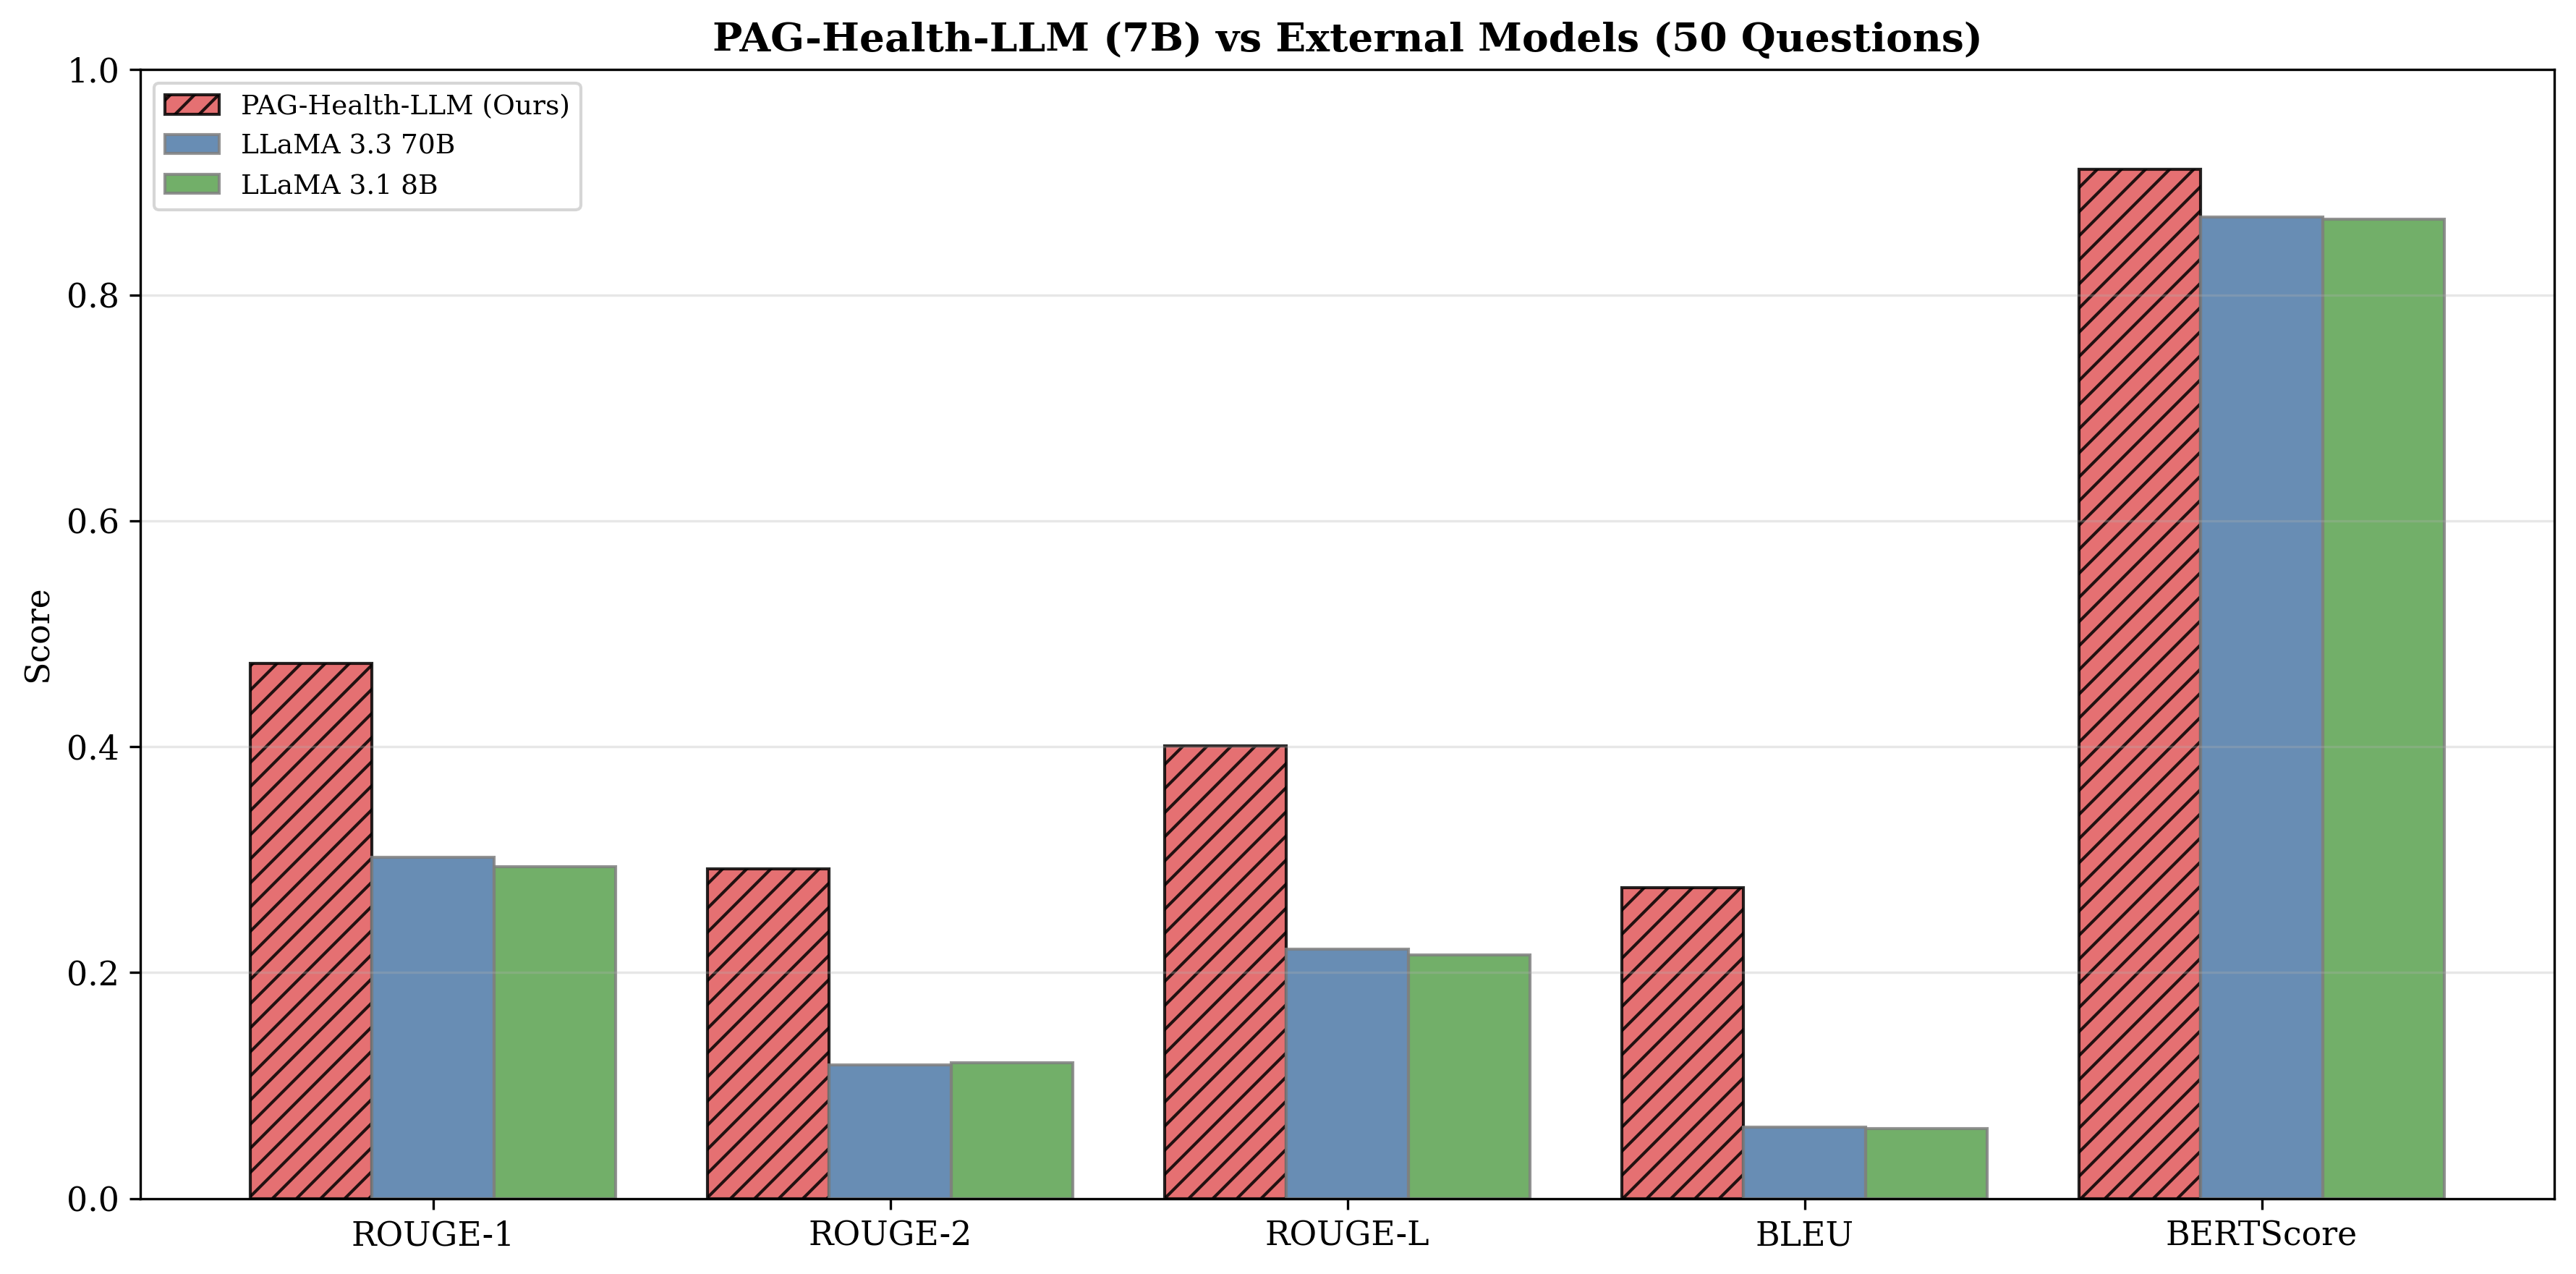

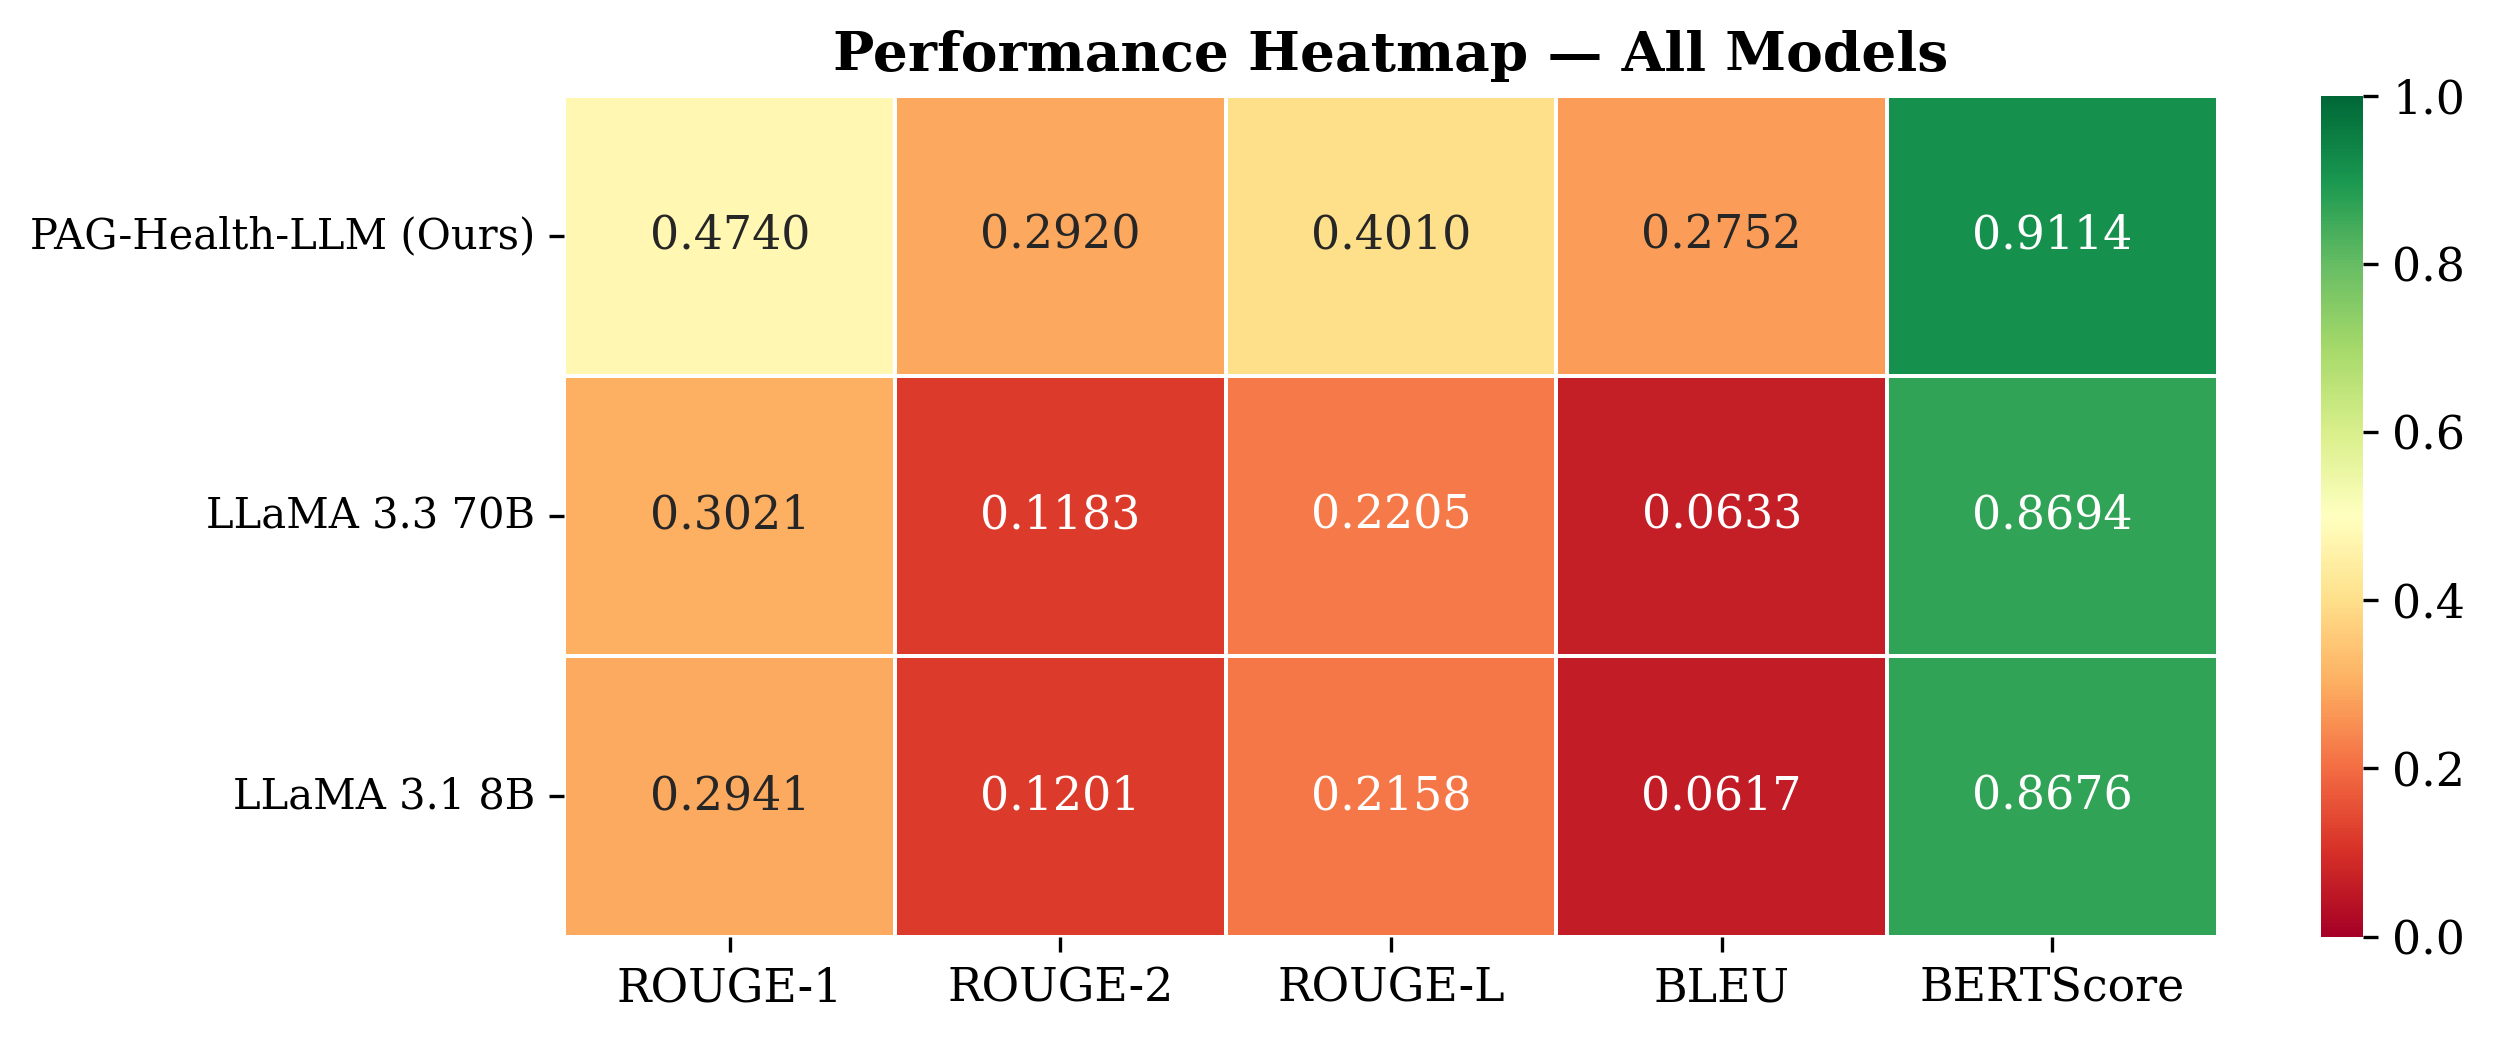

✅ Figures saved


In [12]:
sorted_m = list(df_g['Model'])
n_models = len(sorted_m)
cc_colors = ['#e15759','#4e79a7','#59a14f','#f28e2b'][:n_models]

# Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(MK_L)); w = 0.8/n_models
for i, mn in enumerate(sorted_m):
    means = [np.mean(ext_met[mn][k]) for k in MK_K]
    hatch = '///' if 'Ours' in mn else ''
    edge = 'black' if 'Ours' in mn else 'gray'
    ax.bar(x+i*w, means, w, label=mn, color=cc_colors[i%len(cc_colors)],
           edgecolor=edge, hatch=hatch, alpha=0.85)
ax.set_xticks(x + w*(n_models-1)/2); ax.set_xticklabels(MK_L)
ax.set_title(f'PAG-Health-LLM (7B) vs External Models ({len(test_50)} Questions)', fontweight='bold')
ax.set_ylabel('Score'); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("paper_fig_grand_bar.png", dpi=300, bbox_inches='tight')
plt.savefig("paper_fig_grand_bar.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap
hm = [[np.mean(ext_met[mn][k]) for k in MK_K] for mn in sorted_m]
fig, ax = plt.subplots(figsize=(9, max(3, n_models*1.2)))
sns.heatmap(hm, xticklabels=MK_L, yticklabels=sorted_m,
    annot=True, fmt='.4f', cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Performance Heatmap — All Models', fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("paper_fig_grand_heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig("paper_fig_grand_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figures saved")

### Cell 11 — Fix HuggingFace Space (Update Groq Secret)

In [13]:
from huggingface_hub import HfApi

SPACE_NAME = f"{HF_USERNAME}/PAG-Health-LLM"
api = HfApi(token=HF_TOKEN)

try:
    api.add_space_secret(repo_id=SPACE_NAME, key="GROQ_API_KEY", value=GROQ_API_KEY)
    print(f"✅ Groq API key updated in HuggingFace Space!")
    print(f"   https://huggingface.co/spaces/{SPACE_NAME}")
except Exception as e:
    print(f"⚠️ Auto-update failed: {e}")
    print(f"\n   Manual fix:")
    print(f"   1. Go to https://huggingface.co/spaces/{SPACE_NAME}/settings")
    print(f"   2. Secrets → Replace GROQ_API_KEY with your new key")

✅ Groq API key updated in HuggingFace Space!
   https://huggingface.co/spaces/VahidMonfared/PAG-Health-LLM


### Cell 12 — Launch Colab Web App (Free 72-hour link)

In [14]:
import gradio as gr

def web_answer(question, history):
    if not question.strip():
        return "Please enter a question about pediatric/adolescent gynecology."
    ctx, sources, score = get_rag_context(question, top_k=3)
    if ctx:
        ans = generate(finetuned_model, question, context=ctx)
        src = "\n\n📚 Sources: " + ", ".join(sources)
    else:
        ans = generate(finetuned_model, question)
        src = "\n\n⚠️ General knowledge (topic not in textbook)"
    return ans + src

demo = gr.ChatInterface(
    fn=web_answer,
    title="🏥 PAG Health LLM",
    description="AI for Pediatric & Adolescent Gynecology (NASPAG 2025)\n⚠️ Research tool only.",
    examples=["What are signs of precocious puberty?",
              "How is PCOS diagnosed in adolescents?",
              "What is the treatment for dysmenorrhea?",
              "What are types of amenorrhea?",
              "How to approach contraception for adolescents?"]
)
print("🚀 Launching web app (FREE public URL)...")
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


🚀 Launching web app (FREE public URL)...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d21d4e94a9d404b7b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Cell 13 — Save ALL Results + Download ZIP

In [15]:
import zipfile

zip_fn = "PAG_v5_FIXED_FINAL.zip"
all_f = [
    "comparison_results_all.json",
    "paper_table_grand_comparison.csv",
    "paper_table_significance_vs_all.csv",
    "paper_table_by_question_type.csv",
    "paper_fig_grand_bar.png",
    "paper_fig_grand_bar.pdf",
    "paper_fig_grand_heatmap.png",
    "paper_fig_grand_heatmap.pdf",
    "pag_chunks_v5.json",
    "pag_faiss_index_v5.bin",
    "comp_checkpoint.json",
]

with zipfile.ZipFile(zip_fn, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in all_f:
        if os.path.exists(fn):
            zf.write(fn)
            print(f"  ✅ {fn}")
        else:
            print(f"  ⚠️ Missing: {fn}")

print(f"\n📦 {zip_fn} ready!")
print(f"🎉 DONE! All Phase 6 results fixed.")
files.download(zip_fn)

  ✅ comparison_results_all.json
  ✅ paper_table_grand_comparison.csv
  ✅ paper_table_significance_vs_all.csv
  ✅ paper_table_by_question_type.csv
  ✅ paper_fig_grand_bar.png
  ✅ paper_fig_grand_bar.pdf
  ✅ paper_fig_grand_heatmap.png
  ✅ paper_fig_grand_heatmap.pdf
  ✅ pag_chunks_v5.json
  ✅ pag_faiss_index_v5.bin
  ✅ comp_checkpoint.json

📦 PAG_v5_FIXED_FINAL.zip ready!
🎉 DONE! All Phase 6 results fixed.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from scipy import stats
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score_fn
import nltk
print("✅ All imports loaded")

✅ All imports loaded


In [20]:
from google.colab import files
print("📁 Upload: training_history.json")
uploaded = files.upload()

📁 Upload: training_history.json


Saving training_history.json to training_history (1).json


📁 Upload: PAG_extra_results.ipynb


Saving PAG_extra_results.ipynb to PAG_extra_results (2).ipynb

Running Cell A2...
✅ Loaded 182 test samples with 4-model outputs
   Models: Base Only, Base+RAG, Fine-tuned, Fine-tuned+RAG (Ours)
✅ Loaded training history (17 log entries)

Running Cell A3...


/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


🔄 BERTScore for 4 models...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Fine-tuned: BERTScore = 0.8706


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Fine-tuned+RAG (Ours): BERTScore = 0.9092

✅ All 4-model metrics computed

Running Cell A4...

📊 TABLE 1: 4-MODEL INTERNAL COMPARISON
                Model         ROUGE-1         ROUGE-2         ROUGE-L            BLEU       BERTScore
            Base Only 0.2886 ± 0.1114 0.1059 ± 0.1106 0.2263 ± 0.1105 0.0601 ± 0.0761 0.8698 ± 0.0238
             Base+RAG 0.4637 ± 0.1800 0.2889 ± 0.2023 0.4030 ± 0.1893 0.2678 ± 0.1645 0.9074 ± 0.0316
           Fine-tuned 0.2904 ± 0.1224 0.1134 ± 0.1204 0.2313 ± 0.1212 0.0681 ± 0.0903 0.8706 ± 0.0234
Fine-tuned+RAG (Ours) 0.4748 ± 0.1929 0.2996 ± 0.2150 0.4128 ± 0.1984 0.2848 ± 0.1818 0.9092 ± 0.0326
✅ Saved paper_table1_main_results.csv

Running Cell A5...


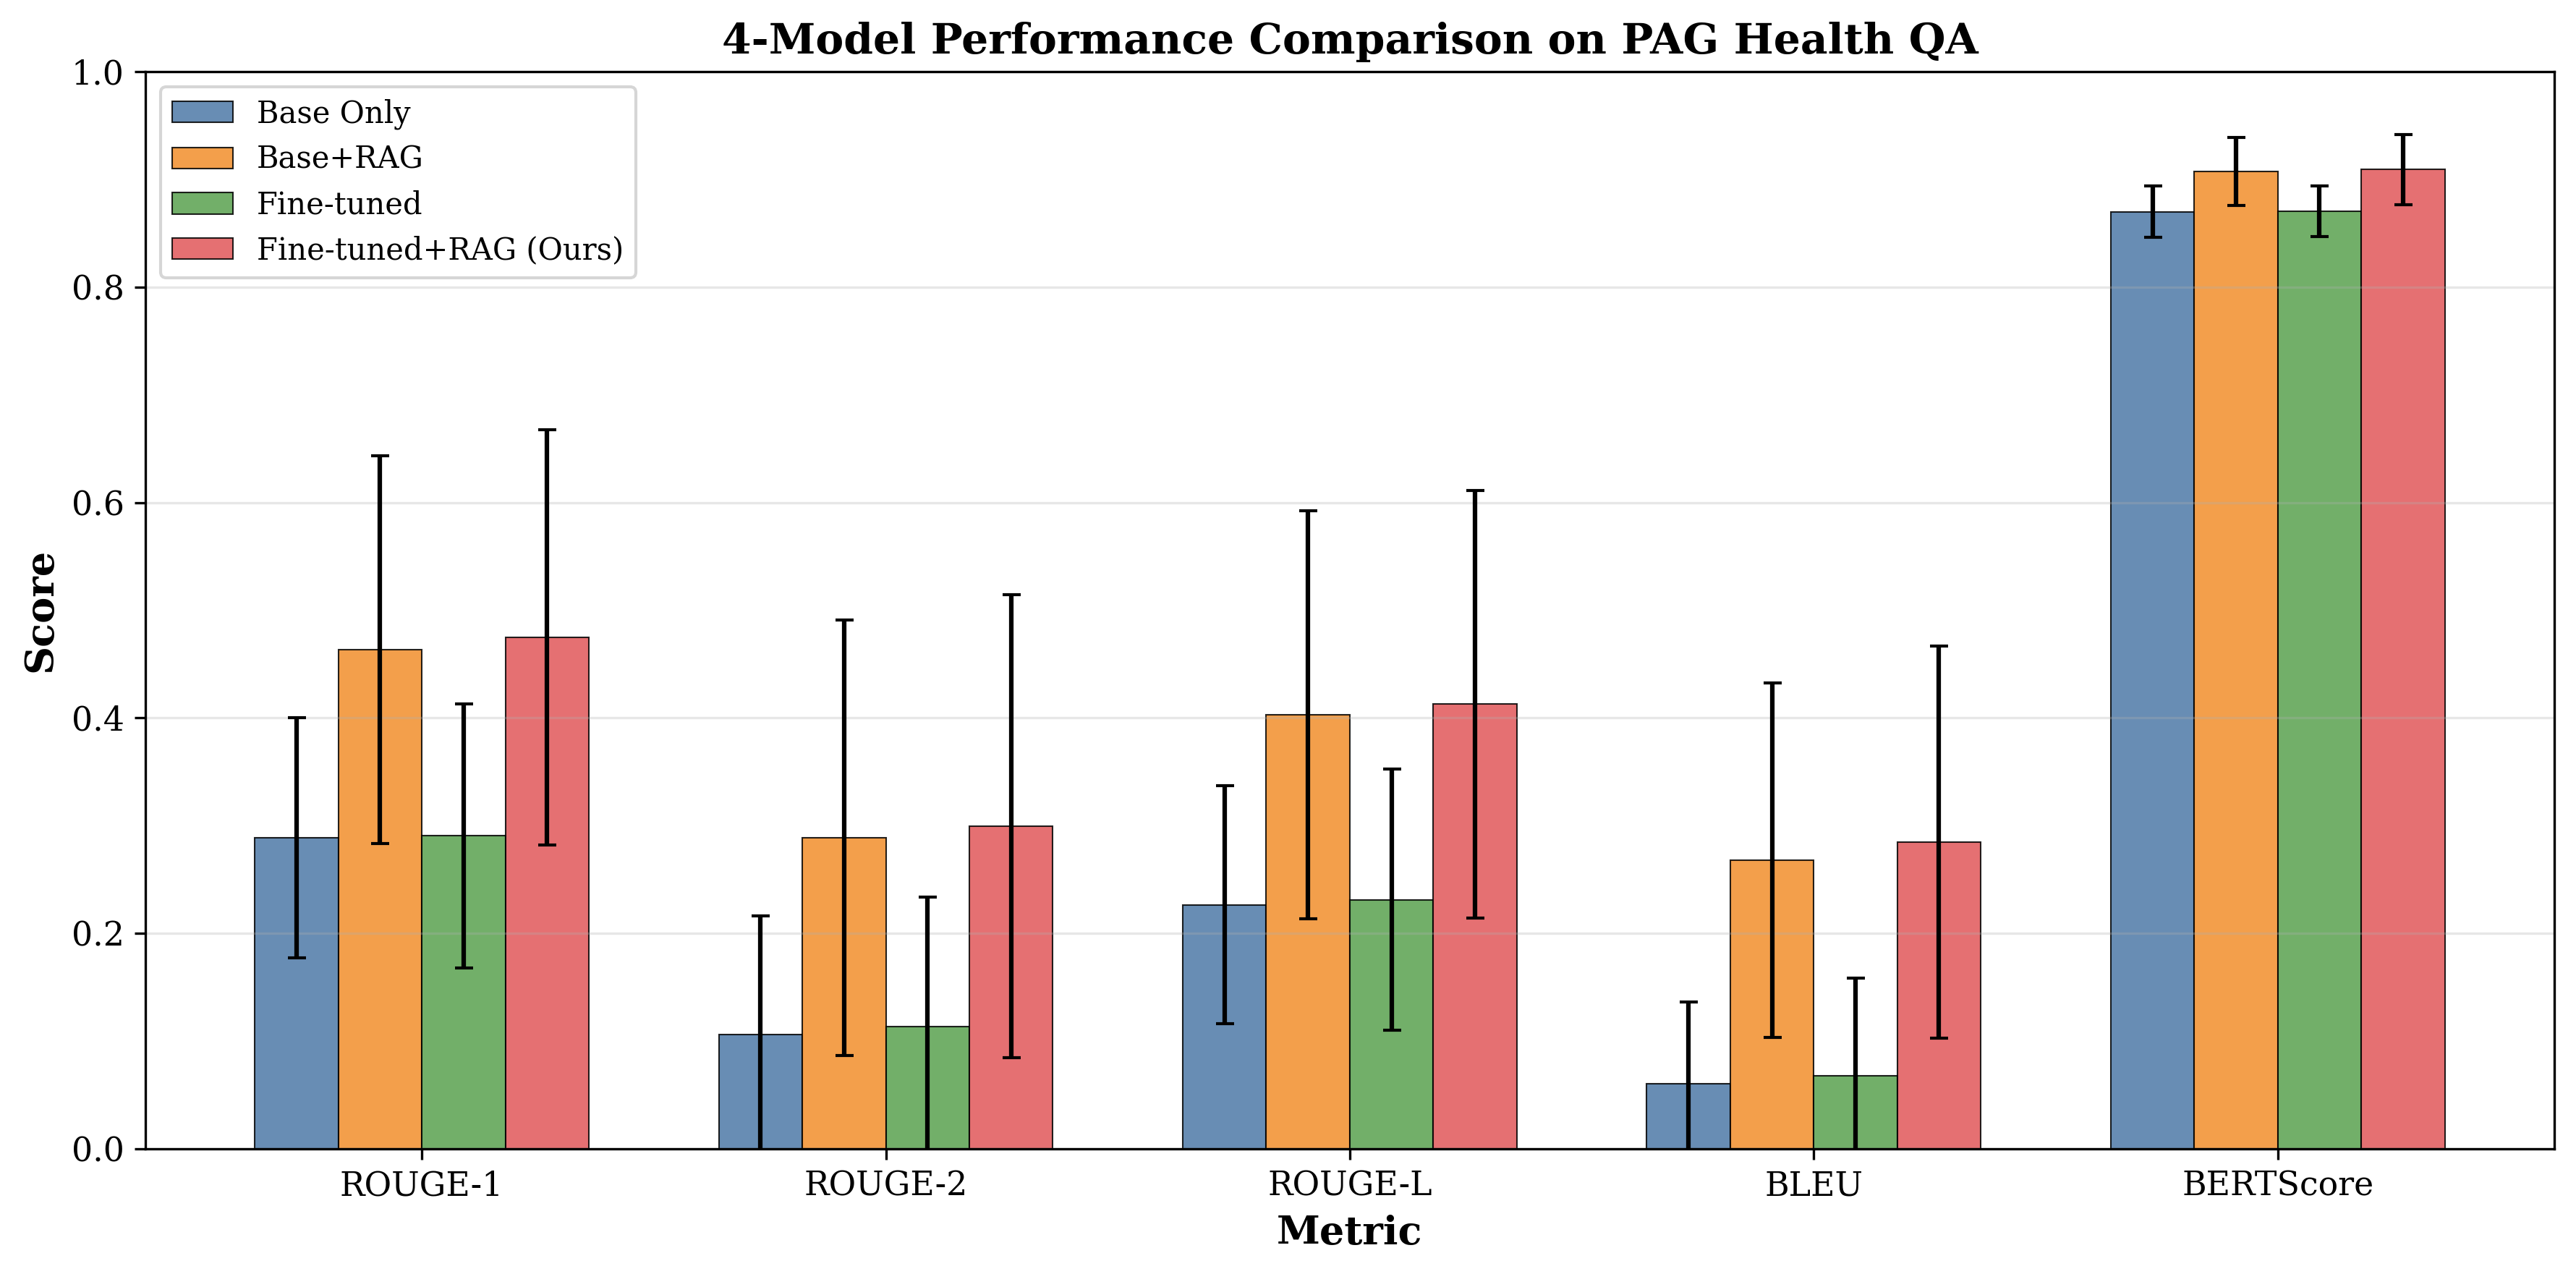

✅ Saved paper_fig1_bar.png/.pdf

Running Cell A6...
📊 TABLE 2: CLASSIFICATION METRICS (threshold=0.88)
  Base Only                 | Acc:0.291 Prec:1.000 Rec:0.291 F1:0.451
  Base+RAG                  | Acc:0.830 Prec:1.000 Rec:0.830 F1:0.907
  Fine-tuned                | Acc:0.330 Prec:1.000 Rec:0.330 F1:0.496
  Fine-tuned+RAG (Ours)     | Acc:0.802 Prec:1.000 Rec:0.802 F1:0.890

✅ Saved paper_table2_classification.csv

Running Cell A7...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


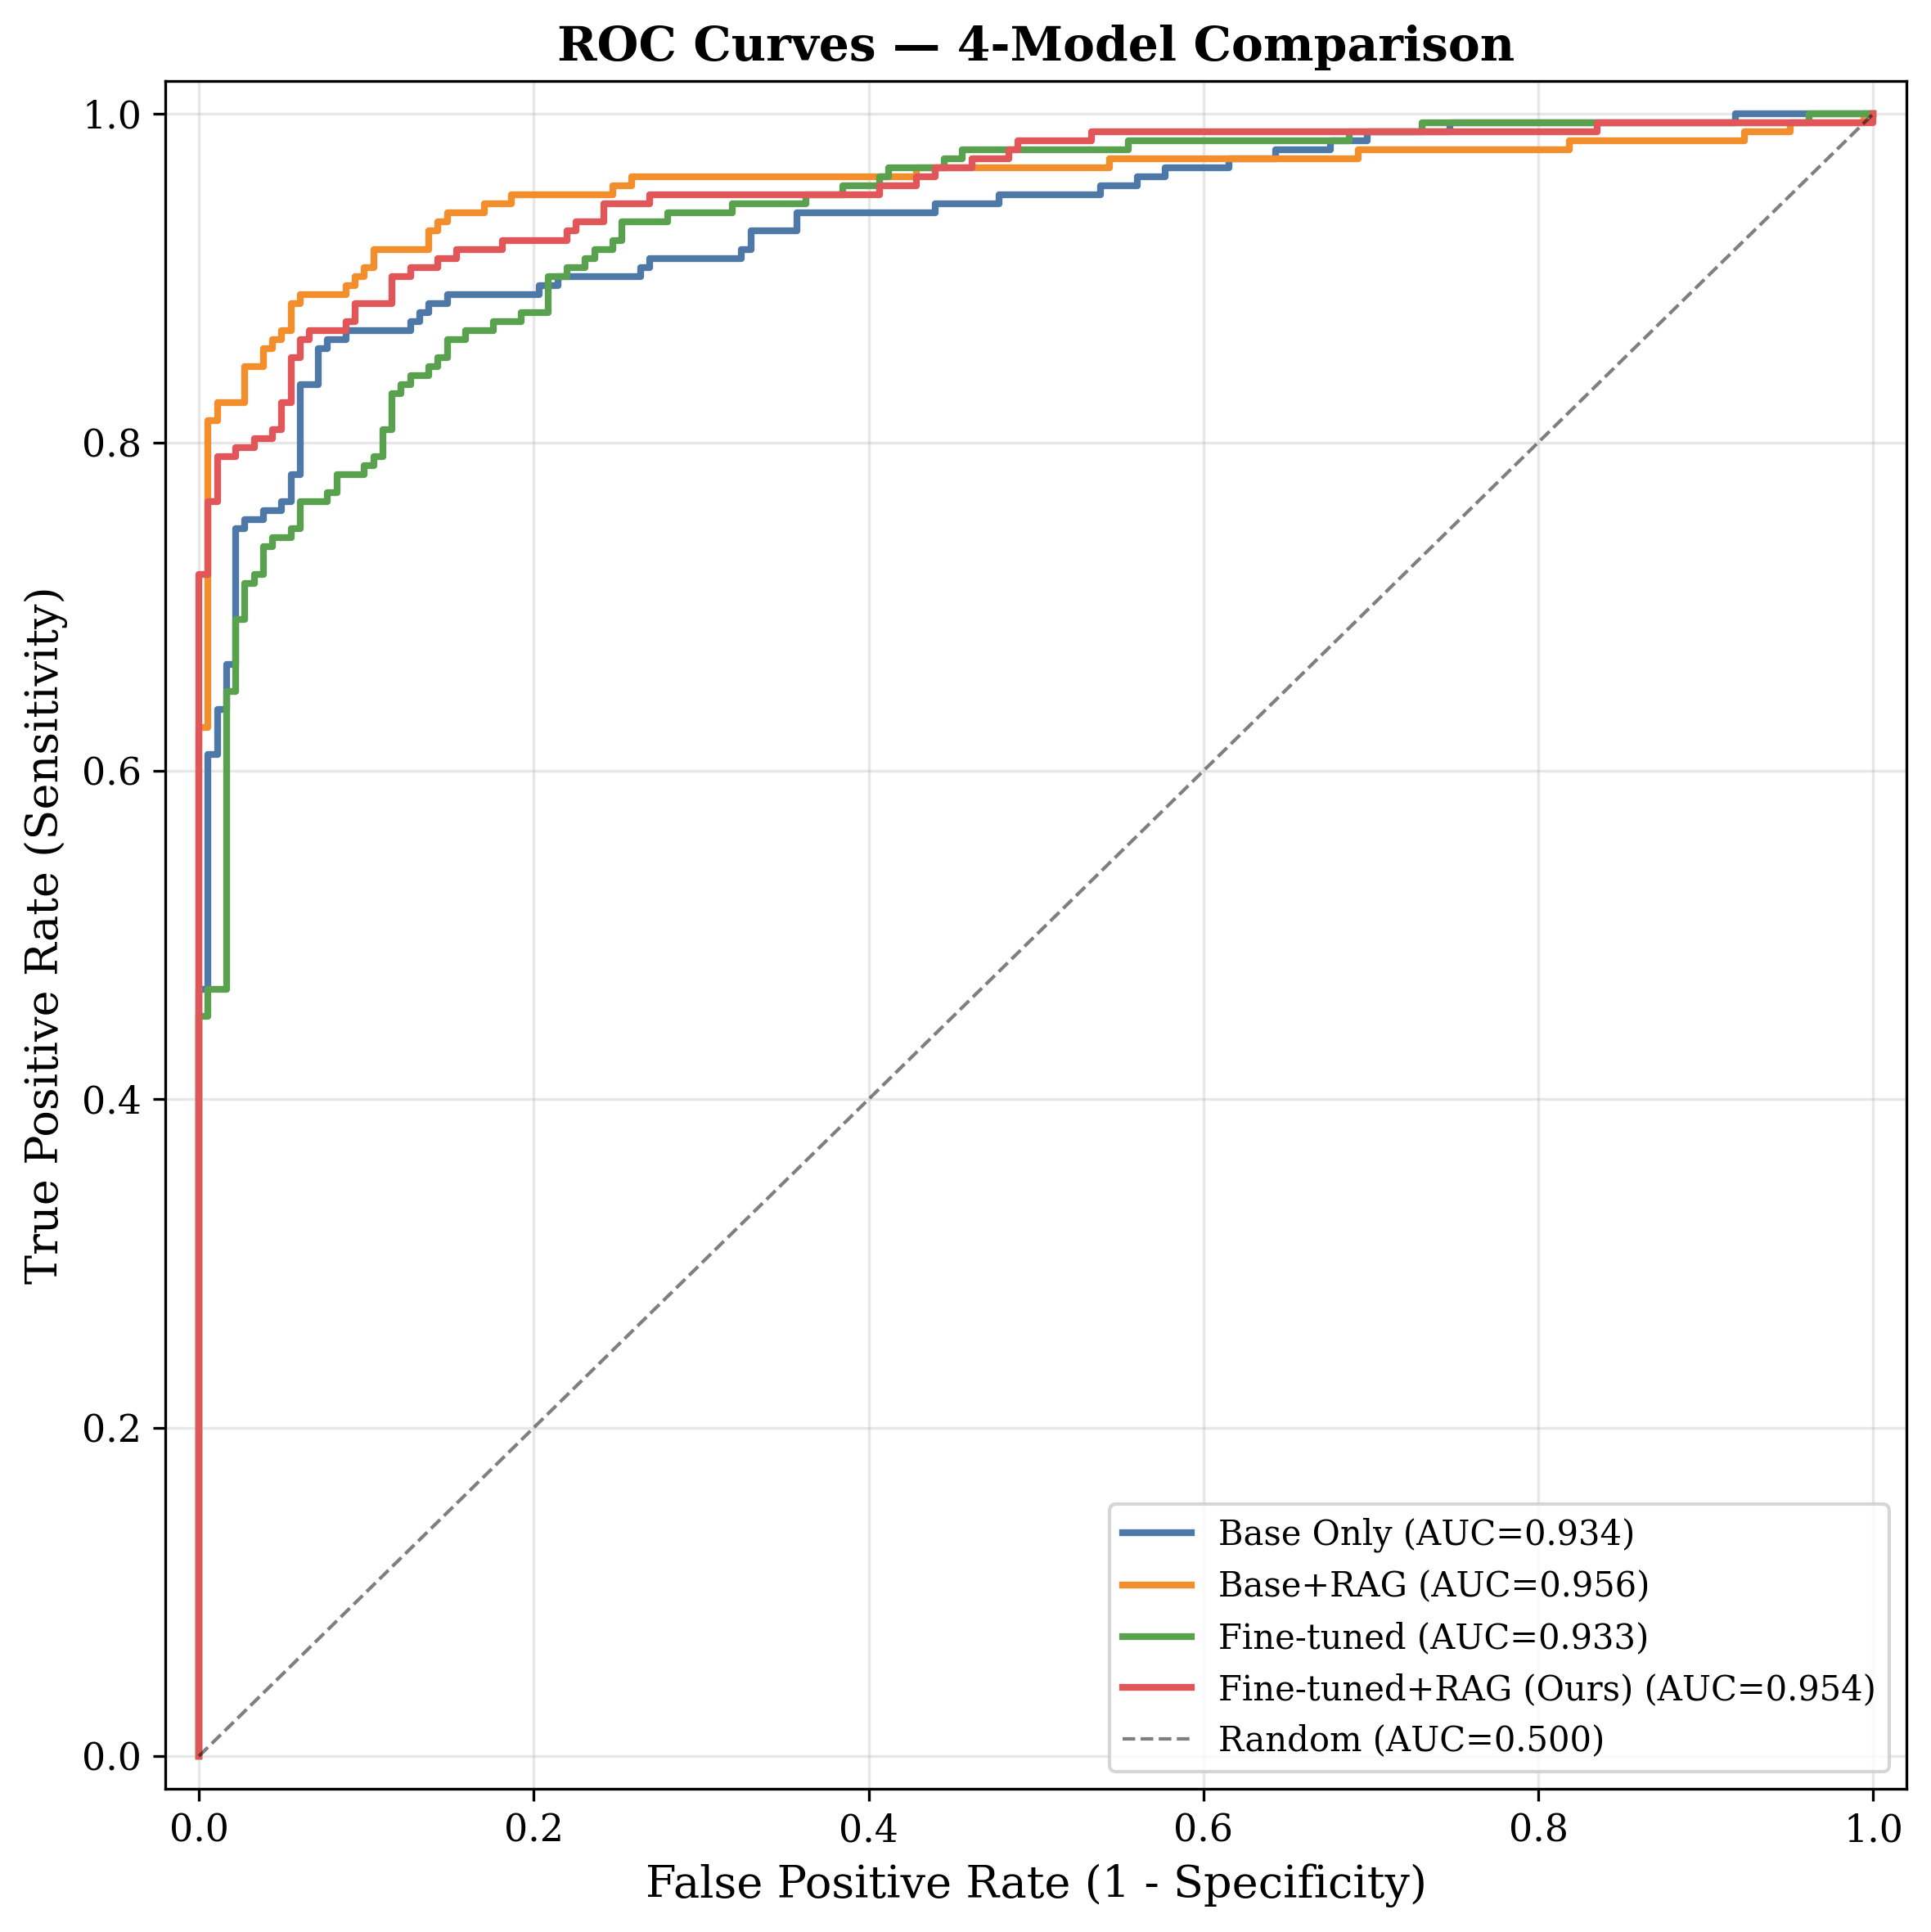

✅ Saved paper_fig2_roc.png/.pdf — with proper AUC curves

Running Cell A8...


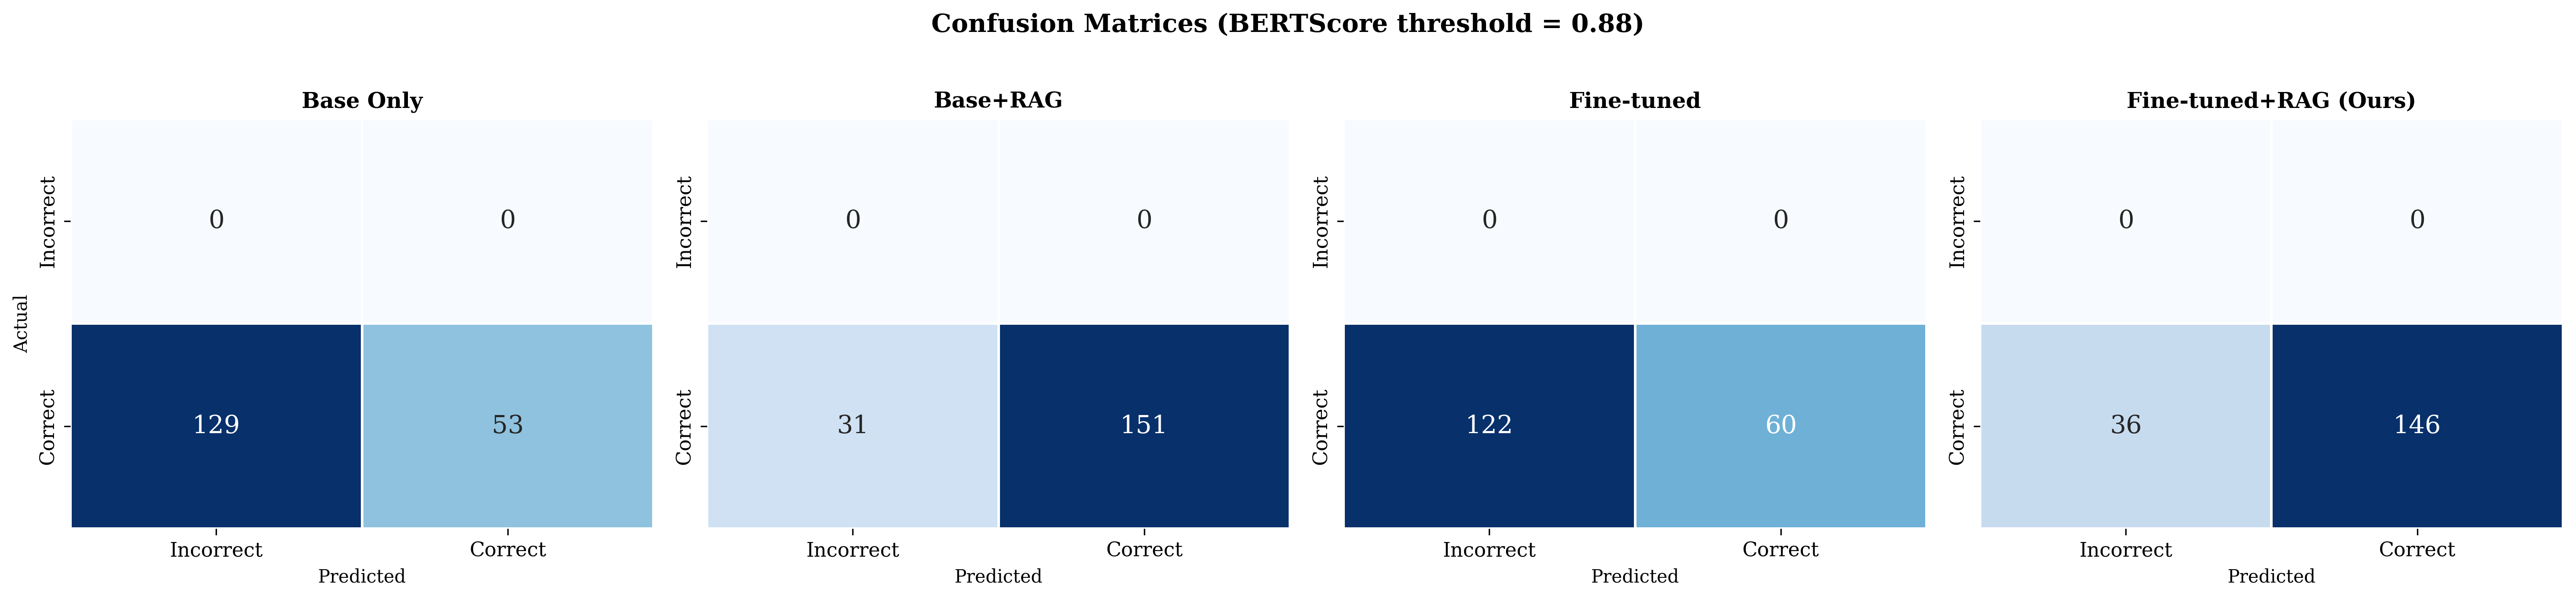

✅ Saved paper_fig3_confusion.png/.pdf

Running Cell A9...


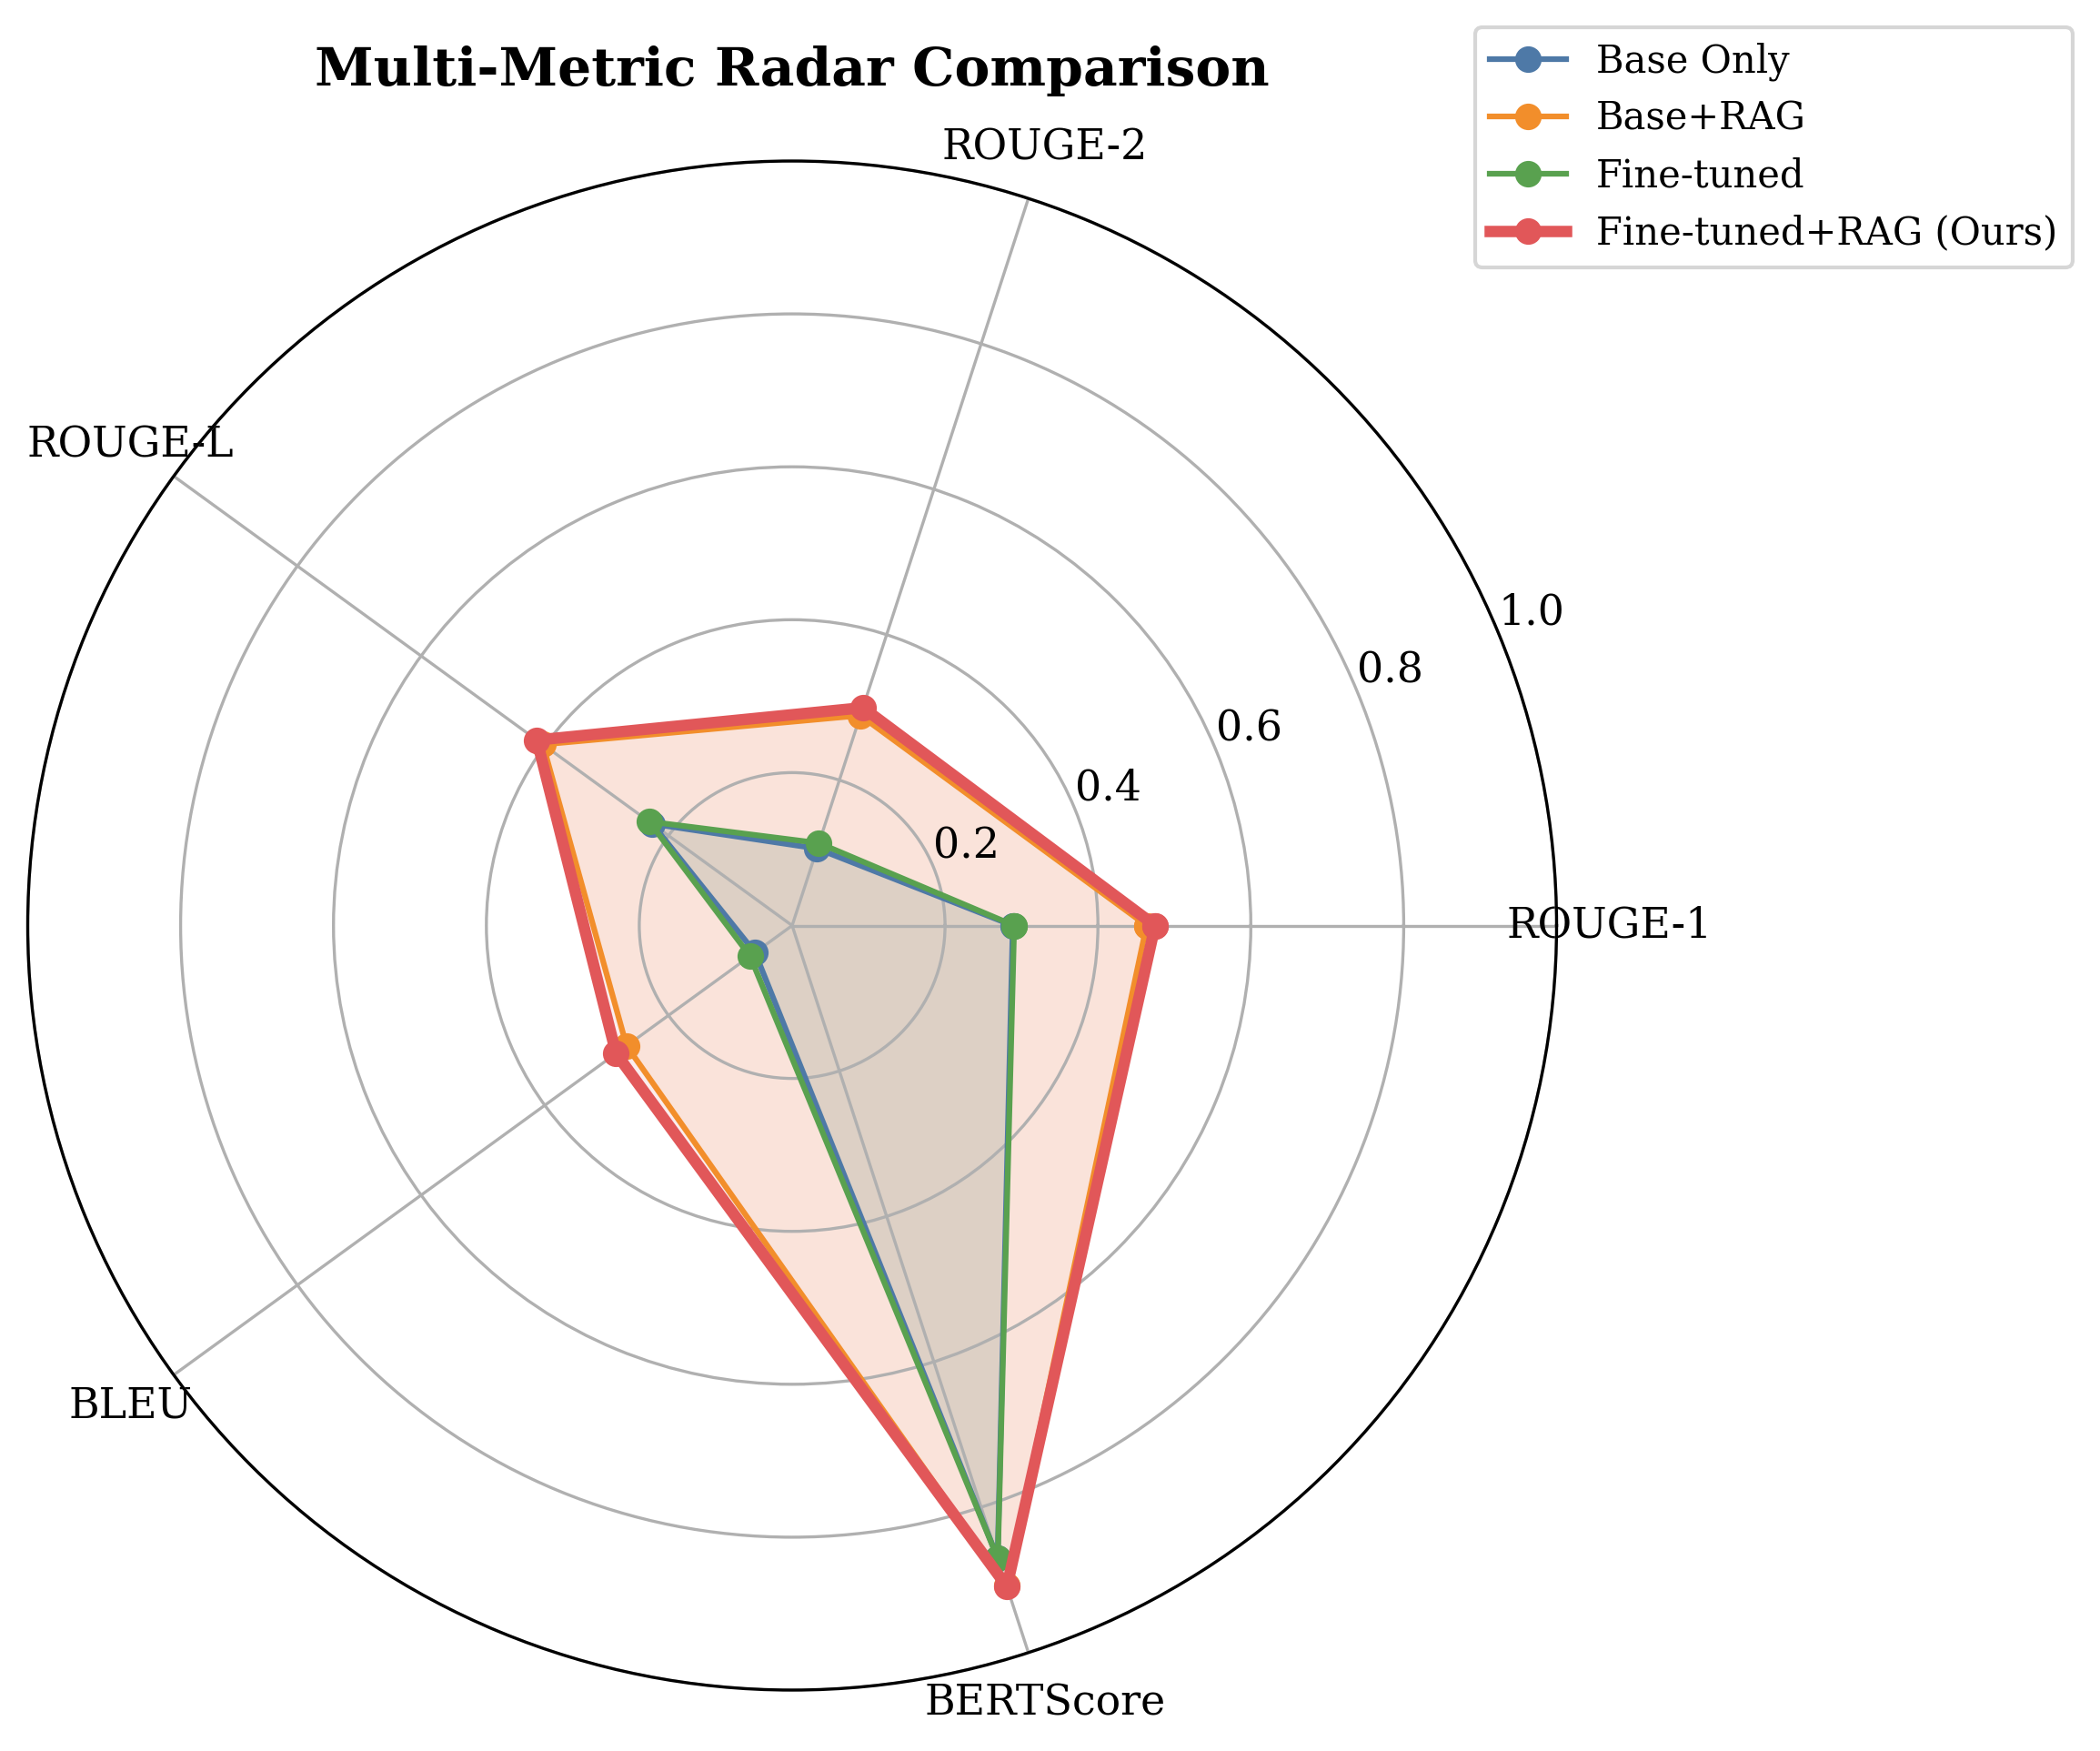

✅ Saved paper_fig4_radar.png/.pdf

Running Cell A10...


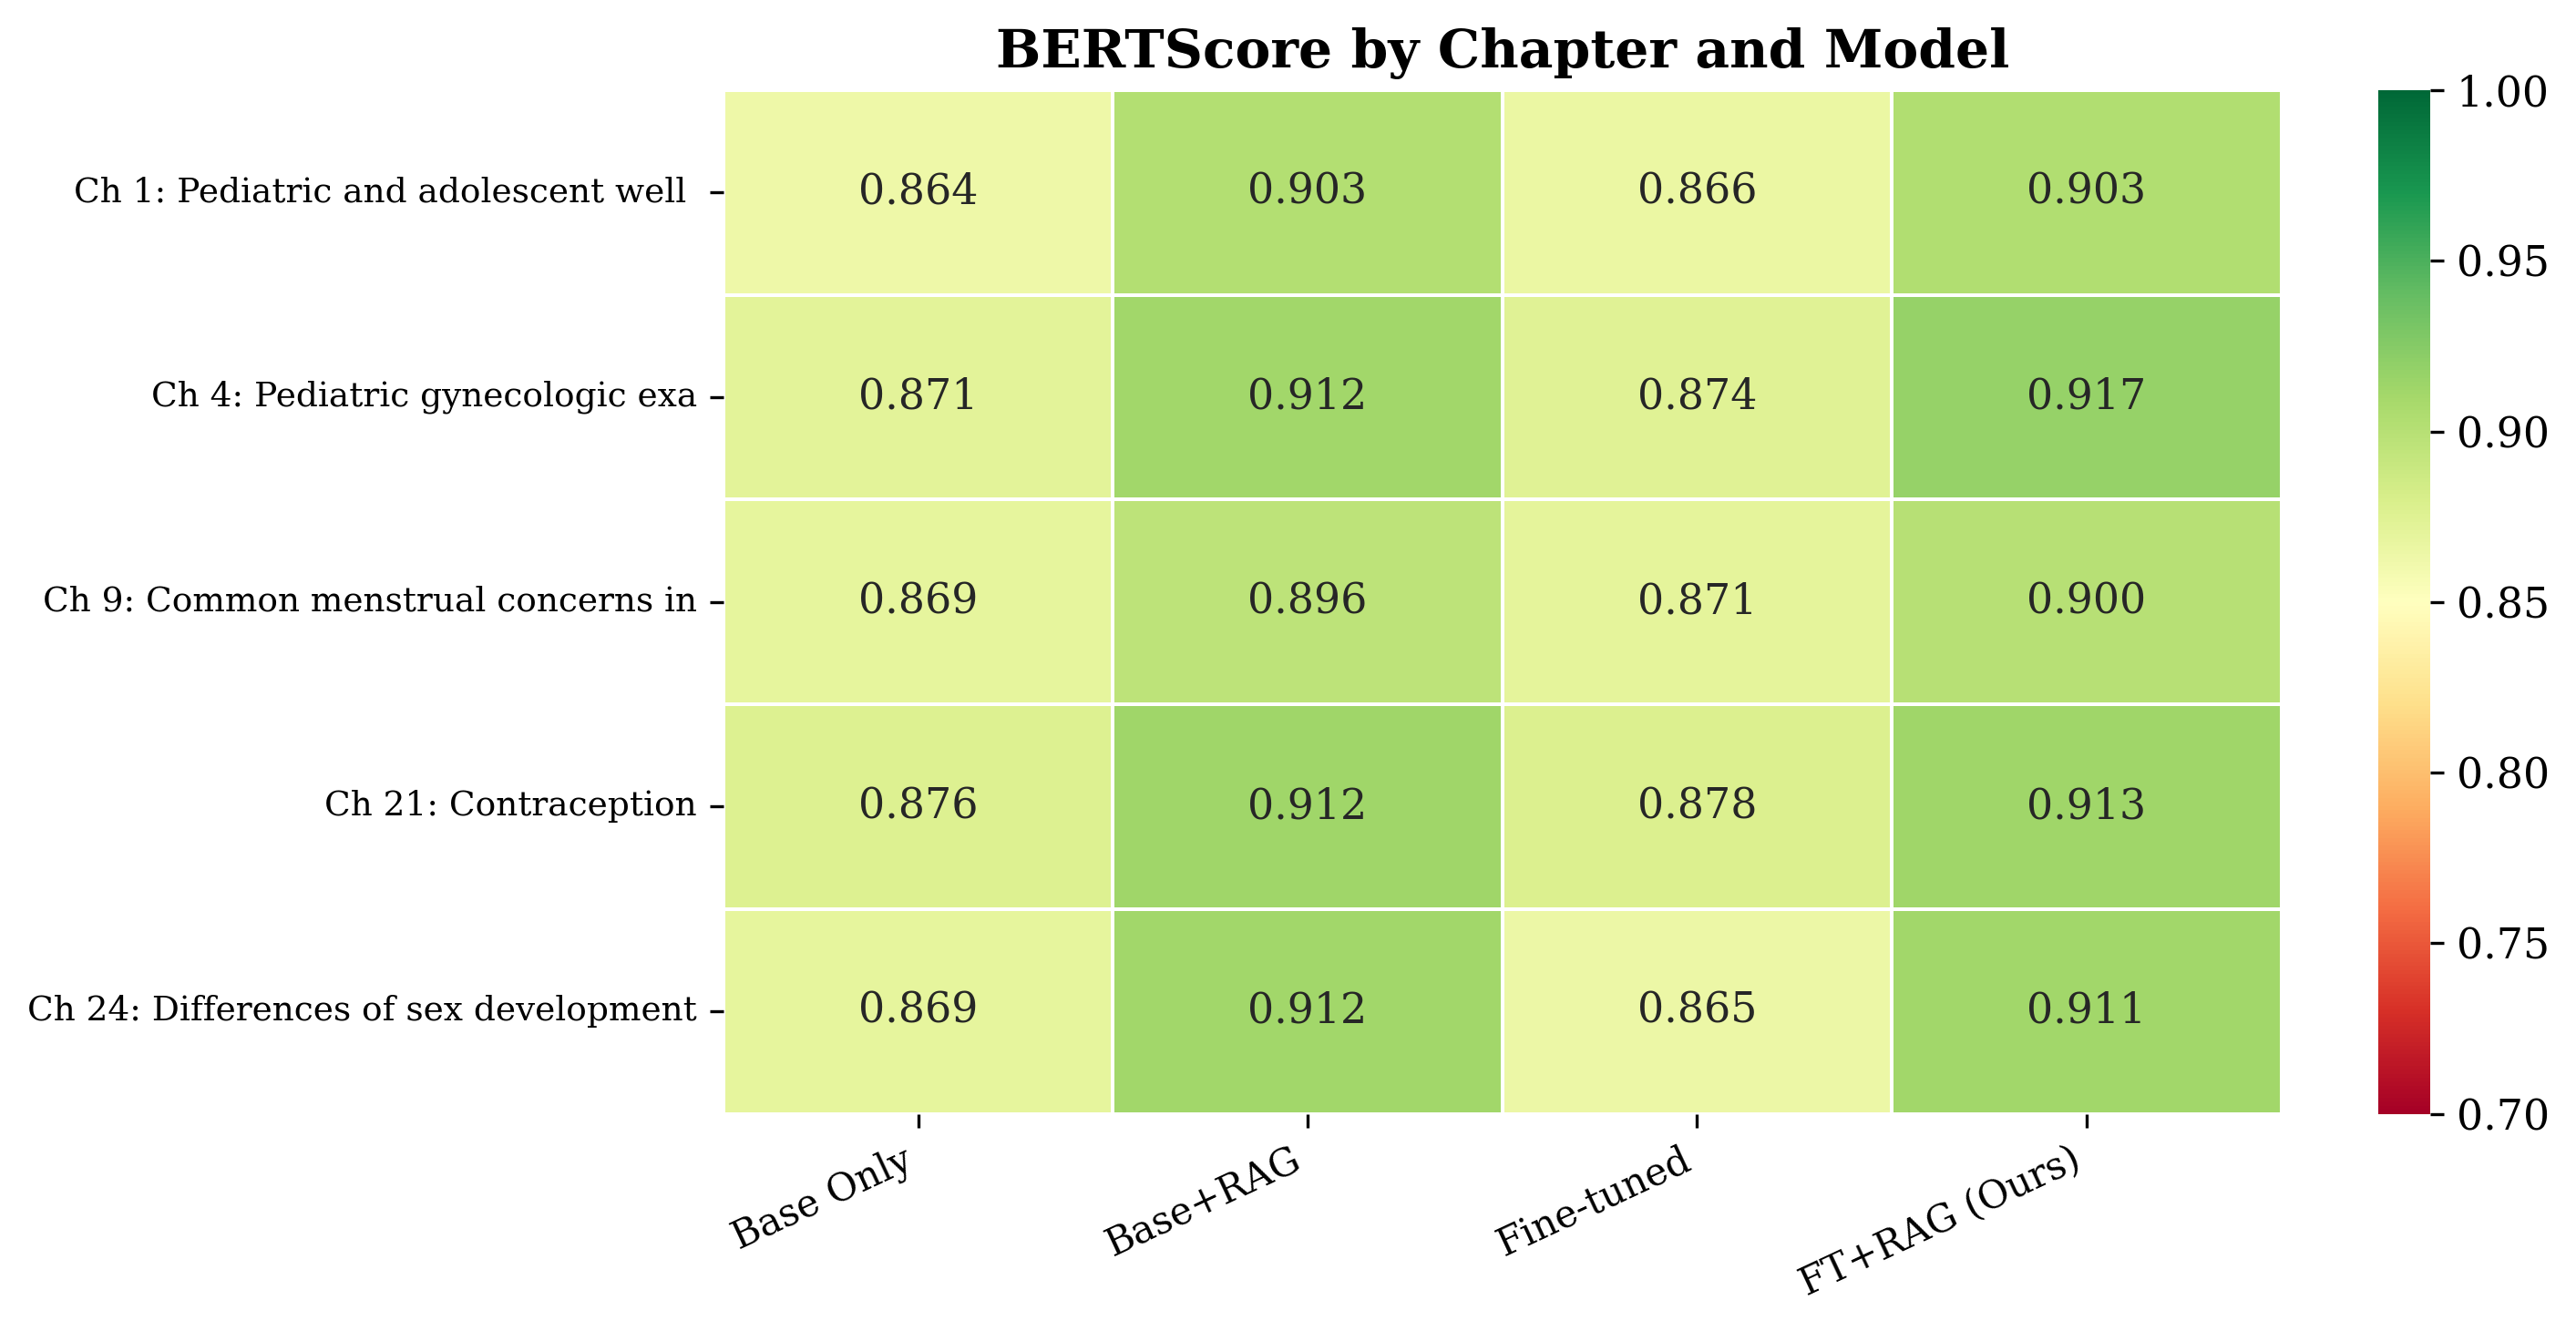

✅ Saved paper_fig5_chapter_heatmap.png — with readable labels

Running Cell A11...


<string>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<string>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<string>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


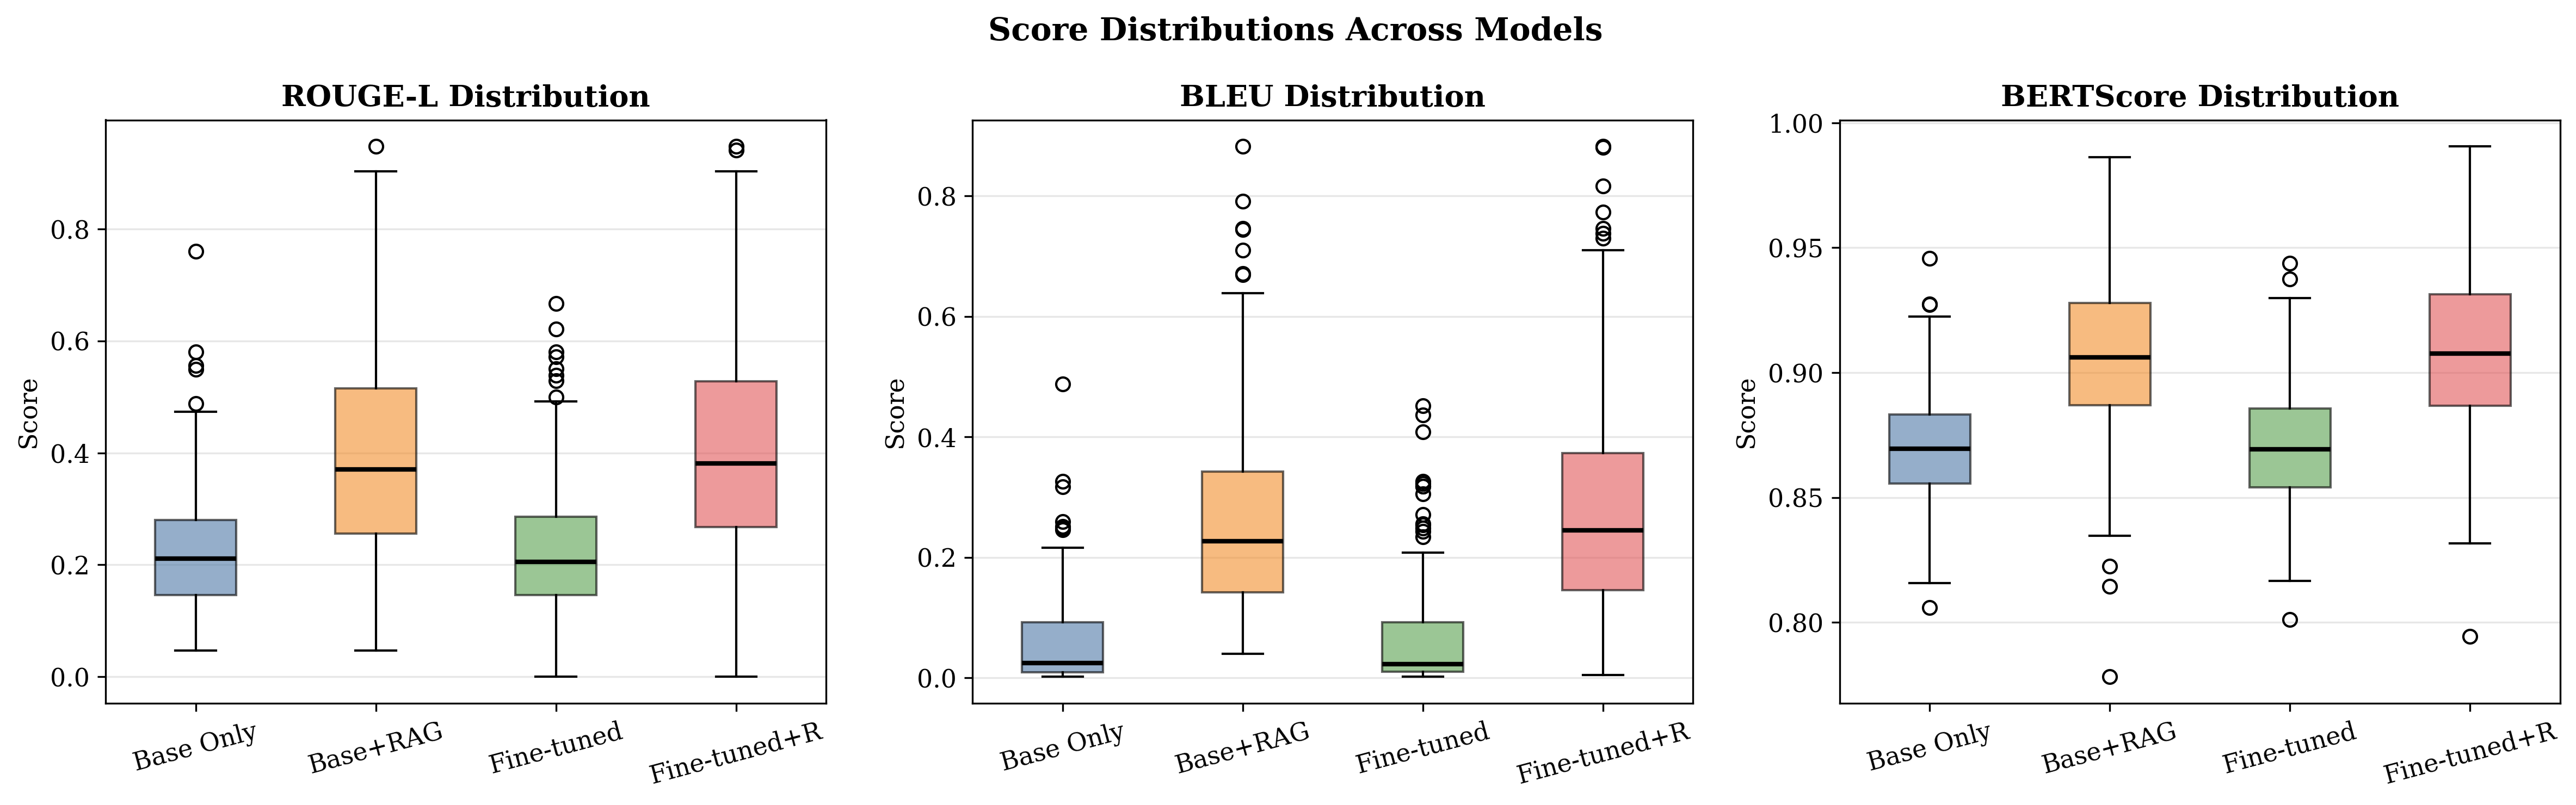

✅ Saved paper_fig6_boxplots.png/.pdf

Running Cell A12...


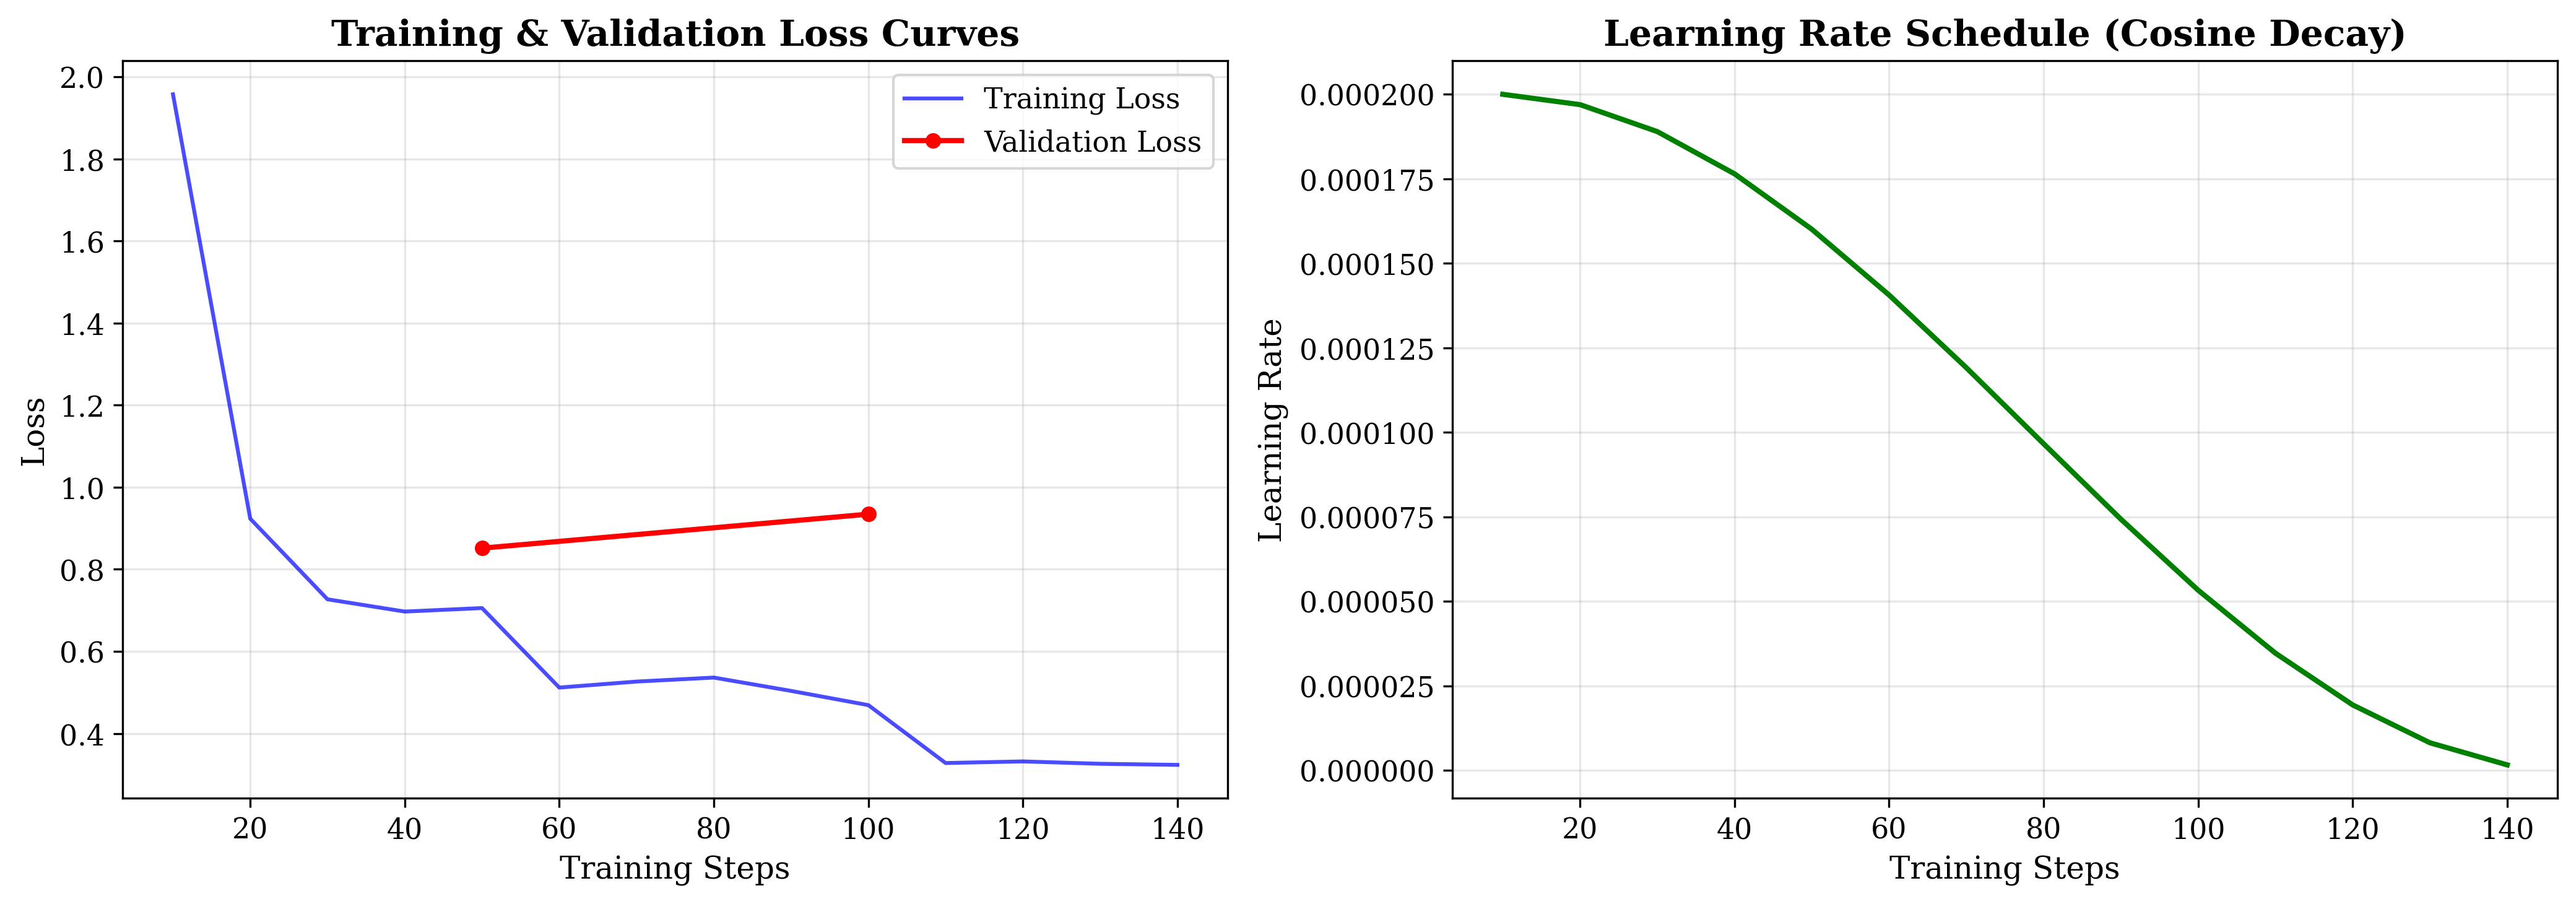

✅ Saved training_curves.png/.pdf
   Best train loss: 0.3235
   Best val loss: 0.8515

Running Cell A13...
📊 FAITHFULNESS SCORES (Higher = Less Hallucination)
  Base Only                : 0.2263 ± 0.1105
  Base+RAG                 : 0.4030 ± 0.1893
  Fine-tuned               : 0.2313 ± 0.1212
  Fine-tuned+RAG (Ours)    : 0.4128 ± 0.1984

✅ Saved paper_table_faithfulness.csv

Running Cell A14...

📊 TABLE 3: STATISTICAL SIGNIFICANCE & IMPROVEMENT
   Metric Base Only FT+RAG (Ours) Difference Improvement  p-value Significance
  ROUGE-1    0.2886        0.4748    +0.1862      +64.5% 3.53e-29          ***
  ROUGE-2    0.1059        0.2996    +0.1937     +183.0% 3.83e-26          ***
  ROUGE-L    0.2263        0.4128    +0.1865      +82.4% 2.01e-28          ***
     BLEU    0.0601        0.2848    +0.2247     +373.9% 1.38e-39          ***
BERTScore    0.8698        0.9092    +0.0393       +4.5% 4.79e-40          ***

  *** p<0.001  ** p<0.01  * p<0.05  ns=not significant

✅ Saved paper_table3_

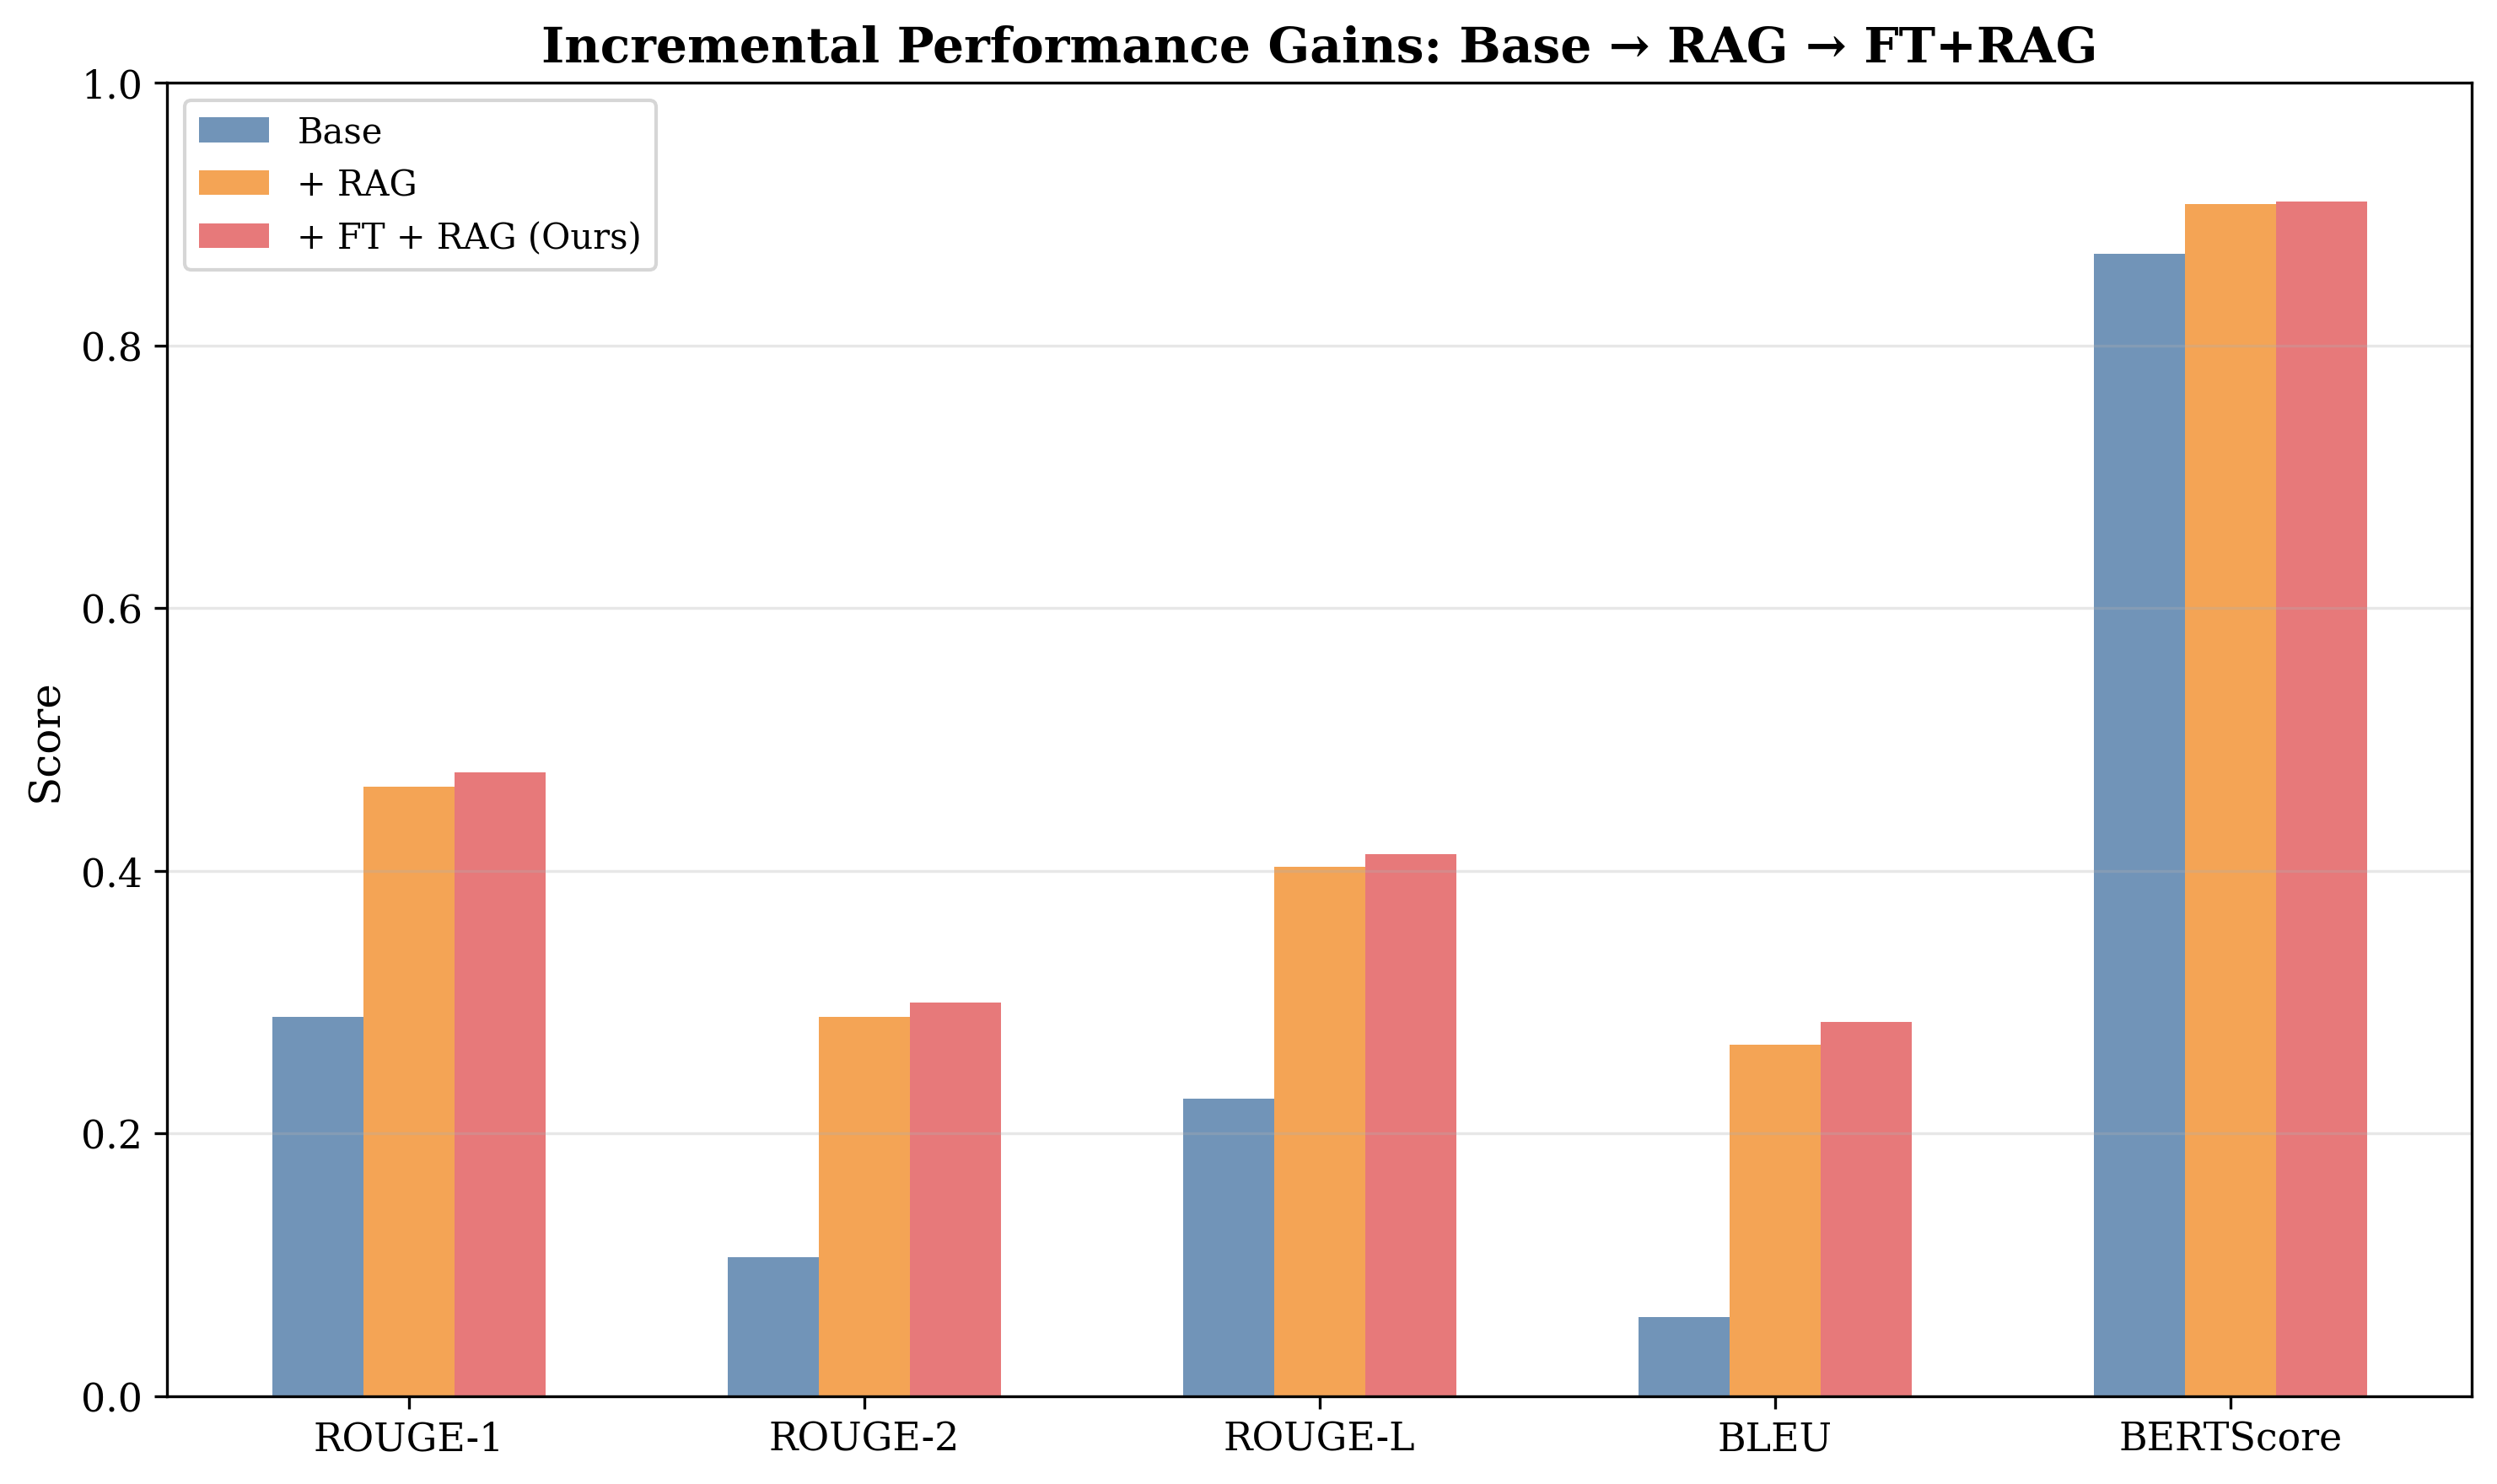

✅ Saved paper_fig8_waterfall.png/.pdf — shows value of each component

Running Cell A17...


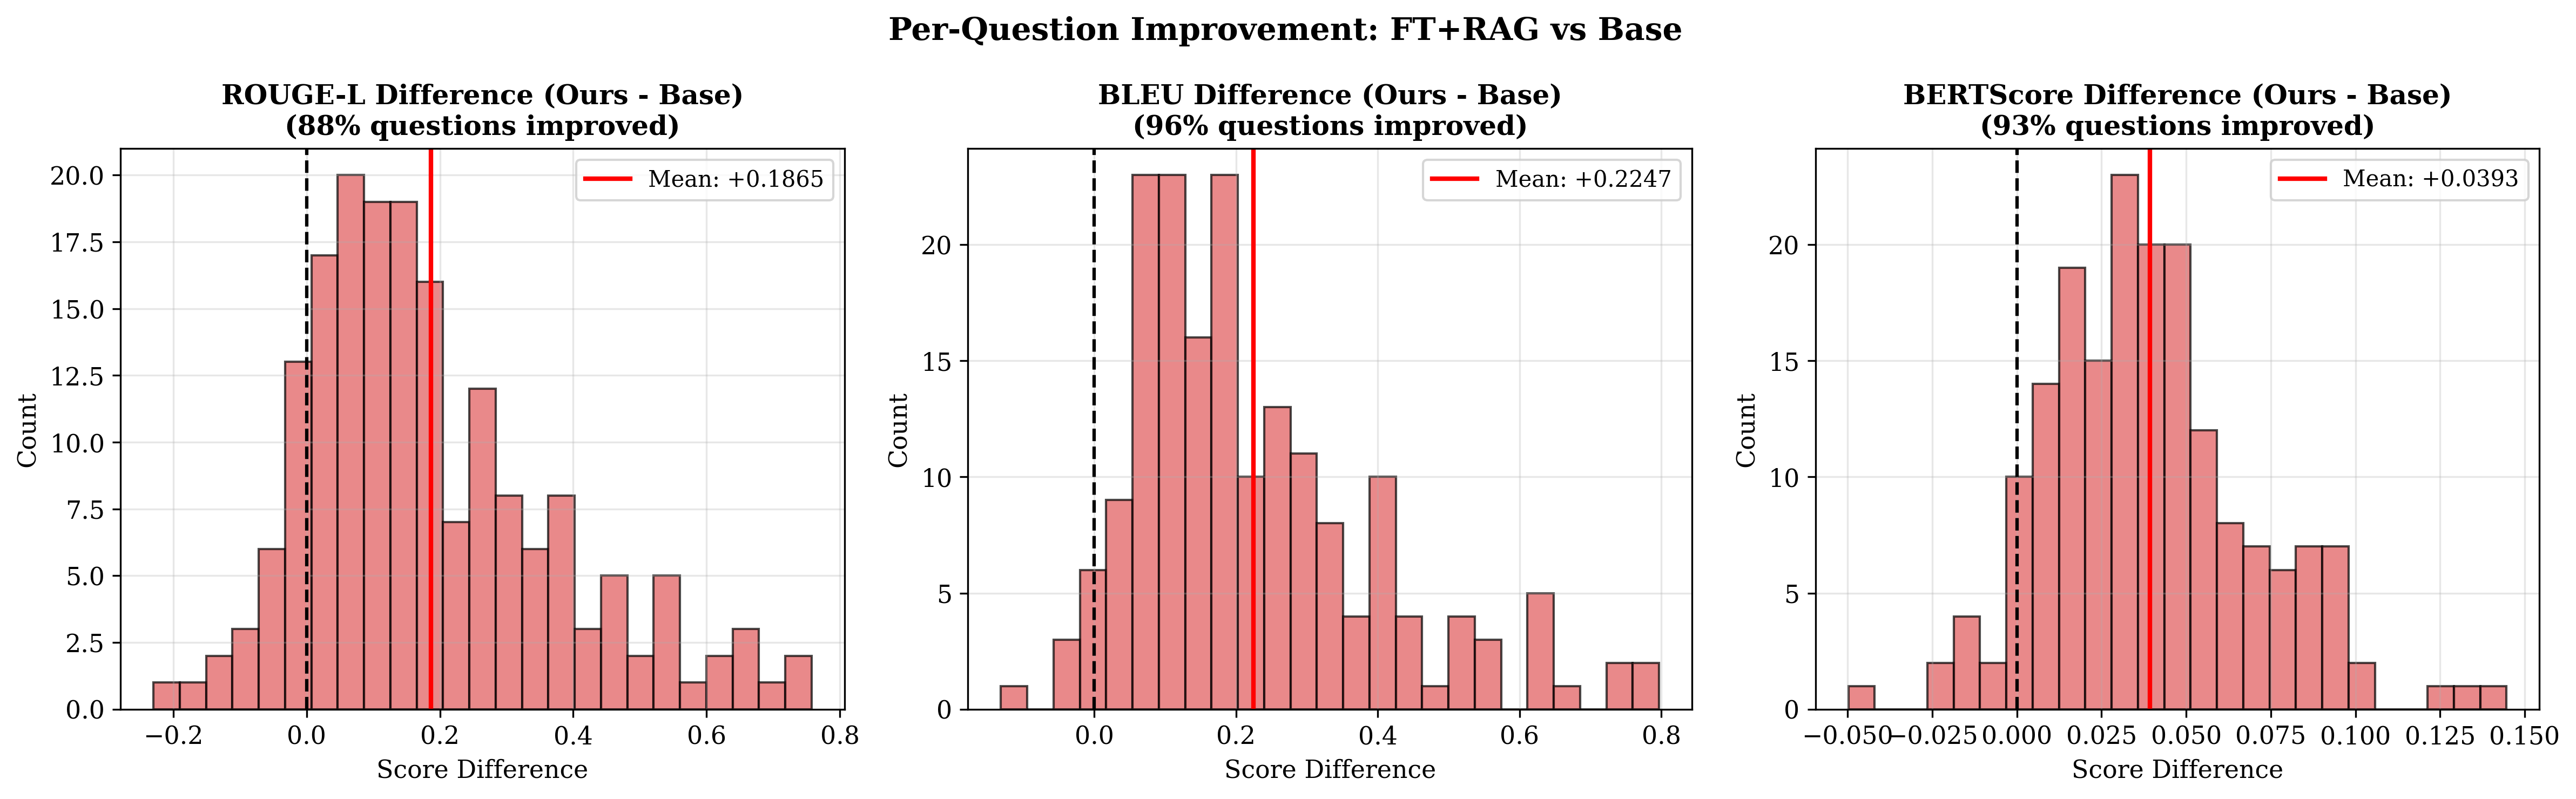

✅ Saved paper_fig9_paired_diff.png/.pdf

Running Cell A18...

📋 COMPLETE SUMMARY OF ALL RESULTS FOR PAPER

🔬 INTERNAL COMPARISON (4 Models, 182 test questions):
   Base Only:          BERTScore = 0.8698
   Base+RAG:           BERTScore = 0.9074
   Fine-tuned:         BERTScore = 0.8706
   FT+RAG (Ours):     BERTScore = 0.9092

🏆 EXTERNAL COMPARISON (3 Models, 50 questions):
   PAG-Health-LLM (Ours)    : BERTScore=0.9114 ROUGE-L=0.4010
   LLaMA 3.3 70B            : BERTScore=0.8694 ROUGE-L=0.2205
   LLaMA 3.1 8B             : BERTScore=0.8676 ROUGE-L=0.2158

📊 KEY IMPROVEMENTS (FT+RAG vs Base, all p<0.001):
   ROUGE-1   : 0.2886 → 0.4748 (+64.5%)
   ROUGE-2   : 0.1059 → 0.2996 (+183.0%)
   ROUGE-L   : 0.2263 → 0.4128 (+82.4%)
   BLEU      : 0.0601 → 0.2848 (+373.9%)
   BERTScore : 0.8698 → 0.9092 (+4.5%)

📁 ALL FILES GENERATED:
   Tables: paper_table1-4, grand_comparison, significance_vs_all, faithfulness
   Figures: paper_fig1-9, grand_bar, grand_heatmap, training_curves

Running Cell 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ALL EXTRA RESULTS GENERATED!


In [21]:
# Download and run extra results notebook
!pip install -q nbformat
import nbformat, IPython

# Upload the extra results notebook
from google.colab import files
print("📁 Upload: PAG_extra_results.ipynb")
uploaded = files.upload()

# Extract and run all code cells from it
with open("PAG_extra_results.ipynb") as f:
    nb = nbformat.read(f, as_version=4)

for i, cell in enumerate(nb.cells):
    if cell.cell_type == 'code':
        print(f"\n{'='*50}\nRunning Cell A{i//2 + 1}...\n{'='*50}")
        exec(cell.source)

print("\n🎉 ALL EXTRA RESULTS GENERATED!")

In [22]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

print("📊 COHEN'S d EFFECT SIZE (Ours vs Base)")
print("="*55)
for k, lab in zip(MK_K, MK_L):
    d = cohens_d(AM4['model_d_ft_rag'][k], AM4['model_a_base'][k])
    size = "Large" if abs(d)>0.8 else "Medium" if abs(d)>0.5 else "Small"
    print(f"  {lab:10s}: d = {d:.3f} ({size})")

print("\n📊 COHEN'S d (Ours vs LLaMA 70B)")
for k, lab in zip(MK_K, MK_L):
    d = cohens_d(ext_met['PAG-Health-LLM (Ours)'][k], ext_met['LLaMA 3.3 70B'][k])
    size = "Large" if abs(d)>0.8 else "Medium" if abs(d)>0.5 else "Small"
    print(f"  {lab:10s}: d = {d:.3f} ({size})")

📊 COHEN'S d EFFECT SIZE (Ours vs Base)
  ROUGE-1   : d = 1.179 (Large)
  ROUGE-2   : d = 1.130 (Large)
  ROUGE-L   : d = 1.158 (Large)
  BLEU      : d = 1.607 (Large)
  BERTScore : d = 1.376 (Large)

📊 COHEN'S d (Ours vs LLaMA 70B)
  ROUGE-1   : d = 1.240 (Large)
  ROUGE-2   : d = 1.226 (Large)
  ROUGE-L   : d = 1.318 (Large)
  BLEU      : d = 1.717 (Large)
  BERTScore : d = 1.819 (Large)
